# Lesson 3a - Metrics, Baselines, and LLM System Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ai-builders/curriculum/blob/main/notebooks/03a_metrics_and_baselines_2026.ipynb)

## What You'll Learn

Welcome to **Metrics, Baselines, and Modern Evaluation**, Lesson 3a of the AI Builders curriculumー2026 edition.

In Lesson 1, you saw that every AI system, whether it is a classical ML model or an LLM pipeline, needs a way to answer: *how good is this?* We introduced loss vs metric, introduced the most common classification and regression metrics, and teased the frontier of LLM evaluation. Now we go deep.

In this notebook you will:

1. **Train-valid-test split**; understand the rules for splitting data fairly, including stratification, time-series ordering, and data leakage.
2. **Classification metrics**; confusion matrix, accuracy, precision, recall, F1, macro/micro averaging, AUROC, AUPRC, what happens when labels are imbalanced, and which baselines to use.
3. **Regression metrics**; MSE, MAE, ~~MAPE~~ (what to use instead), percentage within tolerance, and which baselines to use.
4. **Information retrieval / ranking metrics**; precision@k, recall@k, mAP, MRRーthe same metrics that power RAG evaluation.
5. **Evaluating LLM systems**; semantic similarity, LLM-as-Judge, rubric-based scoring.
6. **Choosing your metrics**; a decision framework by task type, with a reference table for domain-specific metrics covered in later lessons.

Domain-specific metrics (BLEU, ROUGE, IoU, WER, etc.) are covered in their respective lessons (4–6). This notebook focuses on the foundational metrics that apply across most AI/ML systems.

## Environment Setup

The cell below detects whether you are running on **Google Colab** or **locally**.

- **Colab**: dependencies are installed automatically via `pip`.
- **Local** (e.g. MacBook Pro with Apple Silicon): set up your environment with `uv`:

```bash
uv pip install scikit-learn matplotlib pandas numpy \
    dspy torch transformers bitsandbytes accelerate \
    sentence-transformers datasets
```

Or if you have a `requirements.txt`:

```bash
uv pip install -r requirements.txt
```

In [1]:
import os, subprocess, sys

# --- Detect environment ---
IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

LESSON_3_DEPS = [
    "scikit-learn", "matplotlib", "pandas", "numpy",
    "dspy", "torch", "transformers", "bitsandbytes", "accelerate",
    "sentence-transformers", "datasets",
]

if IN_COLAB:
    print("Running on Google Colab — installing dependencies...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *LESSON_3_DEPS]
    )
    print("Done!")
else:
    print("Running locally. Make sure you've set up your environment:")
    print(f"  uv pip install {' '.join(LESSON_3_DEPS)}")
    print("Or: uv pip install -r requirements.txt")

# --- Device setup ---
import torch

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Silicon MPS")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

print(f"\nDevice: {DEVICE}")

Running locally. Make sure you've set up your environment:
  uv pip install scikit-learn matplotlib pandas numpy dspy torch transformers bitsandbytes accelerate sentence-transformers datasets
Or: uv pip install -r requirements.txt
Using Apple Silicon MPS

Device: mps


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Train-Valid-Test Split

One of the most important practices in ML is splitting your data into three parts:

1. **Training set**; the textbooks and exercises. The model learns from these examples. More data, higher quality, and greater diversity all help.

2. **Validation set**; the practice quizzes. You evaluate candidate models here: vary architecture, try different training schemes, tune hyperparameters, and iterate. You may test many model variants against this set before picking the best one. Sometimes called development set, hold-out set, or optimization set.

3. **Test set**; the final exam. You evaluate on the test set **once**, after you have finalized your model on the validation set. The test-set score is the number you report.

### Rules for Splitting

1. **Label distribution should be consistent** across all three sets. If 30 % of your images are cats, each split should have roughly 30 % cats. Use stratified splitting.

2. **Feature distribution should be consistent** too. If your training set has a different GPA distribution than your test set, the model is being evaluated on a different population.

3. **The test set should mirror real-world usage.** If your model will see noisy user photos, the test set should contain noisy user photos, not studio-quality images.

4. **No data leakage.** The same example (or closely related examples) must not appear in both training and validation/test. For example, in patient triaging, the same patient cannot appear in multiple splits; in retail conversion prediction, the same customer cannto appear in multiple splits.

5. **Respect temporal order for time-series.** Train on the oldest data, validate on the next period, test on the most recent. Shuffling time-series data is a common mistake that inflates scores.

A simple 80/10/10 random split works in many cases. But adjust when needed:

- **Severe class imbalance**; you may need to perform sampling strategy to balance the minority class in the training set, while keeping the test set at the natural prevalence. DO NOT use [SMOTE](https://arxiv.org/abs/1106.1813). It has been shown to be not helpful [both theoretically and empirically](https://arxiv.org/pdf/2402.03819).
- **Very small datasets**; use k-fold cross-validation and average the test scores. See [scikit-learn's cross-validation guide](https://scikit-learn.org/stable/modules/cross_validation.html).

In [3]:
from sklearn.model_selection import train_test_split

# Toy data: 10 samples, 3 features
X = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12],[13,14,15],
              [16,17,18],[19,20,21],[22,23,24],[25,26,27],[28,29,30]])
y = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# 80 % train, 10 % valid, 10 % test
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}  Valid: {X_val.shape}  Test: {X_test.shape}")

Train: (8, 3)  Valid: (1, 3)  Test: (1, 3)


## 2. Classification Metrics

Classification predicts a **category** (label) for each example. Two flavors:

1. **Multi-class**; each example has exactly one correct label; for instance, predicting which dog breed is in a photo.
2. **Multi-label**; each example can have multiple correct labels; for instance, predicting which tags apply to a news article (politics, economics, society, possibly all at once).

We focus on multi-class here since the metrics generalize naturally.

### Label Encoding vs One-Hot Encoding

Labels can be represented two ways:

- **Label encoding**; a single column with the class name (or integer).
- **One-hot encoding**; one column per class, with a 1 in the column that matches the label.

In [4]:
# Multi-class example: students and their favorite football team
data_mc = {
    "student_id": [123, 152, 768, 998, 776],
    "favorite_team": ["Man_United", "Liverpool", "Man_United", "Chelsea", "Man_City"],
}
df_mc = pd.DataFrame(data_mc)

# One-hot encoding
df_mc_ohe = pd.get_dummies(df_mc, columns=["favorite_team"]).astype(int)
df_mc = df_mc.merge(df_mc_ohe, on="student_id")
df_mc

,student_id,favorite_team,favorite_team_Chelsea,favorite_team_Liverpool,favorite_team_Man_City,favorite_team_Man_United
0,123,Man_United,0,0,0,1
1,152,Liverpool,0,1,0,0
2,768,Man_United,0,0,0,1
3,998,Chelsea,1,0,0,0
4,776,Man_City,0,0,1,0


The number of distinct labels (here 4: Man_United, Liverpool, Chelsea, Man_City) is called the **cardinality** of the label set.

### Confusion Matrix

Almost every classification metric is derived from the confusion matrix. Rows are the **true labels**, columns are the **predicted labels**. A perfect model has all counts on the diagonal.

In [5]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# --- Synthetic dog-breed classification dataset (balanced) ---
dog_breeds = [
    "Labrador Retriever", "German Shepherd",
    "Golden Retriever", "Bulldog", "Poodle",
]
np.random.seed(125)
num_samples = 300
actuals = np.random.choice(dog_breeds, size=num_samples)
randoms = np.random.choice(dog_breeds, size=num_samples)

# A model that is decent but makes realistic mistakes
prediction_logic = {
    "Labrador Retriever": ["Labrador Retriever", "Golden Retriever", "Poodle"],
    "German Shepherd":    ["German Shepherd", "Labrador Retriever", "Golden Retriever"],
    "Golden Retriever":   ["Golden Retriever", "Labrador Retriever", "Poodle"],
    "Bulldog":            ["Bulldog", "Golden Retriever"],
    "Poodle":             ["Poodle", "Labrador Retriever", "Golden Retriever"],
}
predictions = [np.random.choice(prediction_logic[a]) for a in actuals]

df = pd.DataFrame({"actual": actuals, "pred": predictions, "pred_random": randoms})
print(f"{len(df)} samples, {df.actual.nunique()} breeds")
df.head(10)

300 samples, 5 breeds


,actual,pred,pred_random
0,Golden Retriever,Poodle,German Shepherd
1,Bulldog,Golden Retriever,Poodle
2,Poodle,Labrador Retriever,Poodle
3,Bulldog,Bulldog,Golden Retriever
4,Bulldog,Bulldog,German Shepherd
5,Labrador Retriever,Labrador Retriever,Bulldog
6,Golden Retriever,Labrador Retriever,Bulldog
7,Bulldog,Golden Retriever,Labrador Retriever
8,Golden Retriever,Poodle,Bulldog
9,Labrador Retriever,Poodle,Labrador Retriever


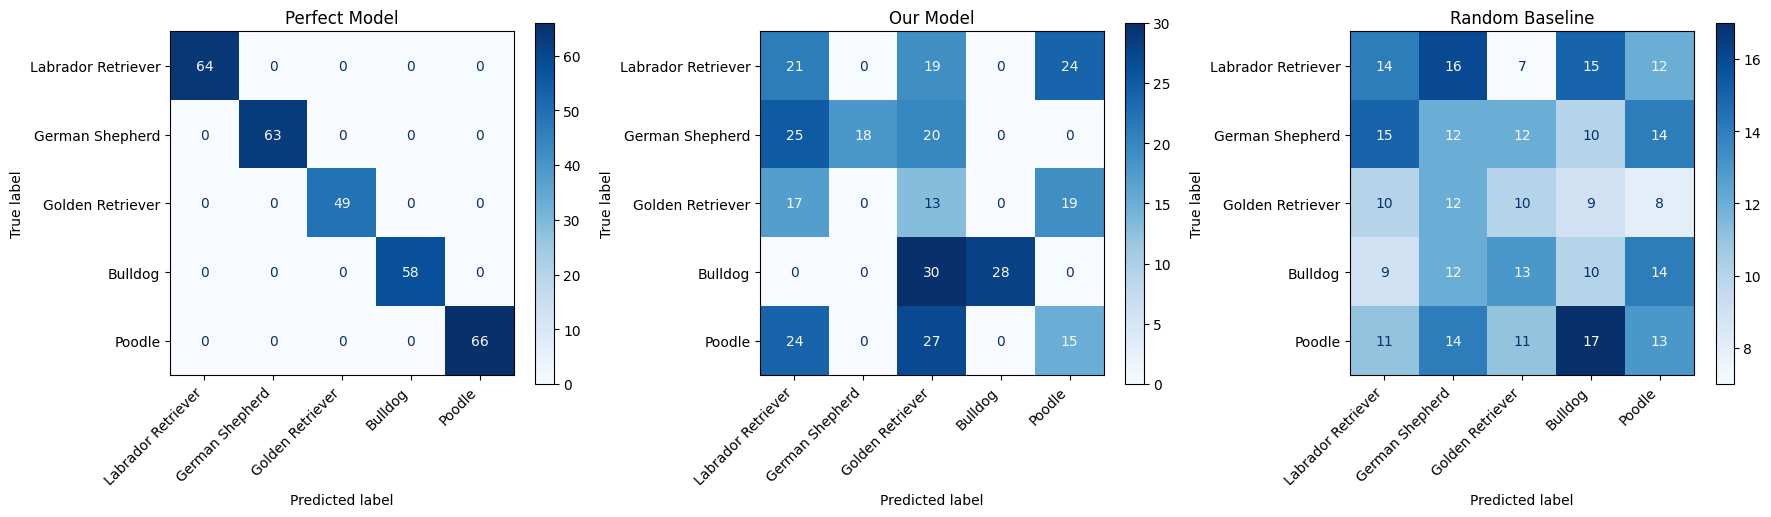

In [6]:
# Perfect model — everything on the diagonal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    df.actual, df.actual, labels=dog_breeds, ax=axes[0], cmap="Blues",
)
axes[0].set_title("Perfect Model")

# Our model
ConfusionMatrixDisplay.from_predictions(
    df.actual, df.pred, labels=dog_breeds, ax=axes[1], cmap="Blues",
)
axes[1].set_title("Our Model")

# Random baseline
ConfusionMatrixDisplay.from_predictions(
    df.actual, df.pred_random, labels=dog_breeds, ax=axes[2], cmap="Blues",
)
axes[2].set_title("Random Baseline")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Reading the confusion matrix:**

- Diagonal cells = correct predictions. Off-diagonal = mistakes.
- Row *i*, column *j* = "the model predicted class *j* when the true class was *i*."
- Our fake model confuses Golden Retrievers with Labradors and Poodles, which makes sense visually.
- The random baseline spreads predictions uniformly, no structure at all.

> **Exercise** Let's test our understanding with a set of simple exercises.
> 1. How many actual `Poodle` did our model classified as `Golden Retriever`?
> 2. Among those our predicted as `Golden Retriever`, how many dogs are actually so?
> 3. How many of true`German Sheperd` did our model miscalssified? As which breeds?
> 4. Among all dogs our model classified as `Poodle`, what are their true breeds?
> 5. How many of true `Labrador Retriever` did our model miscalssified? As which breeds?

**Answer Key**

1. 27 dogs

2. 13 dogs

3. `Labrador Retriever` (25), `Golden Retriever` (20)

4. `Poodle` (15), `Golden Retriever` (19), Labrador Retriever (24)

5. `Golden Retriever` (19) and `Poodle` (24)

### Classification Baselines

Before celebrating your model's performance, compare it against baselines:

1. **Majority-class**; always predict the most common label. If 40 % of your data is Poodle, predict Poodle every time.
2. **Random**; predict a random label with uniform probability.

If your model cannot beat *at least* these, it has not learned anything useful.

Majority class: Poodle (66/300 = 22.0%)


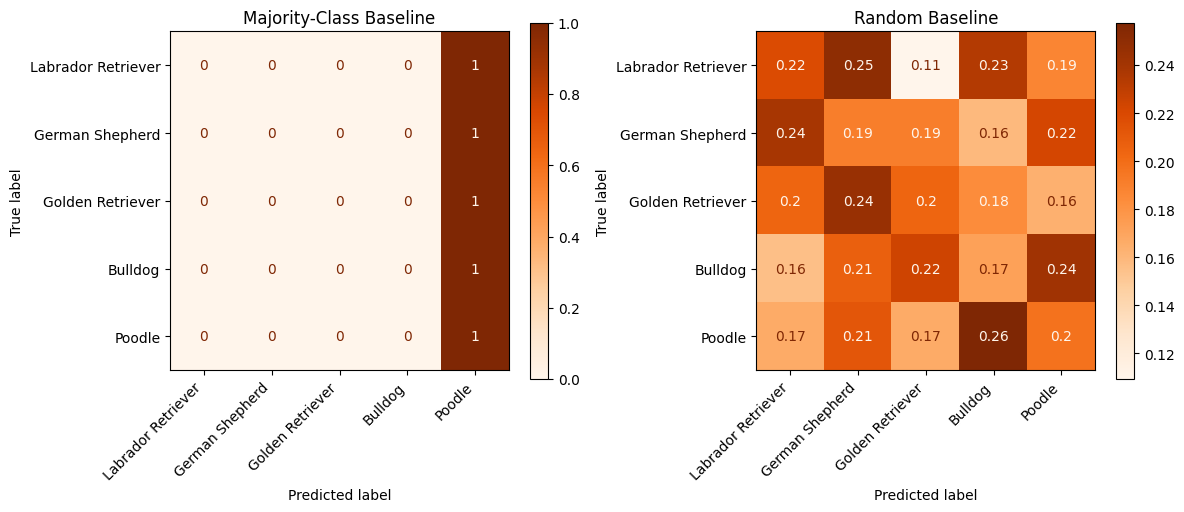

In [7]:
# Majority-class baseline: always predict the most common breed
majority_class = df.actual.value_counts().index[0]
df["pred_majority"] = majority_class
print(f"Majority class: {majority_class} ({df.actual.value_counts().iloc[0]}/{len(df)} = {df.actual.value_counts(normalize=True).iloc[0]:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    df.actual, df.pred_majority, labels=dog_breeds, ax=axes[0], cmap="Oranges", normalize="true"
)
axes[0].set_title("Majority-Class Baseline")

ConfusionMatrixDisplay.from_predictions(
    df.actual, df.pred_random, labels=dog_breeds, ax=axes[1], cmap="Oranges", normalize="true"
)
axes[1].set_title("Random Baseline")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

Other common baselines (not limited to classification) include:

3. **Existing Models**; chances are you are not the first person who ever thought about solving the problem you are trying to solve. Search [HuggingFace](https://huggingface.co/models), [Kaggle](https://www.kaggle.com/), [Google Scholar](https://scholar.google.com/), [Papers with Code](https://paperswithcode.com/) and [Github](https://github.com/) for existing models and see how they do on your test set.

4. **Heuristics**; Simple rules like a couple of if-else logic gates can be a surprisingly strong baseline sometimes. For instance, if you are classifying customers who are likely to churn, there is a high probability that such a simple rule like `if not visit in the last 6 months, then predict churn` will do really well.

5. **Humans**; used to be the baseline with the highest quality albeit costly/time-consuming to collect data from, but now can underperform LLMs.

6. **Zero-shot LLMs**; if Claude/Gemini/ChatGPT/Qwen or other major LLMs can perform your task well without any training, there is a high chance that either your task is too easy or your model is underperforming.

### Accuracy, Precision, Recall, and F1

**Accuracy** is the simplest metric: what fraction of predictions are correct? But it can be misleading when classes are imbalanced (more on that below).

To get a fuller picture, we compute **per-class** metrics:

- **Precision**; of all examples the model predicted as class *C*, how many actually were *C*? aka true positive over *column-wise* sum of the confusion matrix. Optimize for this if the cost of false positive is high.

*For example, predicting a stock will go up to invest in, but it actually goes down.*

- **Recall**; of all examples that actually were class *C*, how many did the model catch? aka true positive over *row-wise* sum of the confusion matrix. Optimize for this if the cost of false negative is high.

*For example, predicting a person is healthy in a health checkup, but they actually have cancer.*


> **Exercise** Precision or Recall, Which Matters More? For each scenario, decide whether you would prioritize precision or recall. There is no definitive right answer. The goal is to think about the cost of each type of mistake.
> 1. A hospital uses a model to screen patients for a rare but life-threatening disease. Patients flagged by the model get an expensive follow-up test.
> 2. An email provider builds a spam filter. Emails classified as spam are automatically deleted and the user never sees them.
> 3. A content moderation system flags social media posts that contain hate speech for removal.
> 4. A recommendation system suggests products on an e-commerce homepage. Showing 5 items the user sees immediately.
> 5. A factory quality control system inspects products on an assembly line. Flagged products are pulled off the line and manually re-inspected.
> 6. A law enforcement system scans security footage to identify suspects on a wanted list.

**Answer Key**

1. Recall — missing a sick patient (false negative) could be fatal. Better to over-flag and do extra tests.
2. Precision — deleting a legitimate email (false positive) is worse than letting some spam through. Users can tolerate spam in their inbox but not missing important emails.
3. Depends — letting hate speech stay up (false negative) causes real harm. Too conservative moderation (false positive) violates free speech.
4. Precision — you only have 5 slots. Showing irrelevant products (false positives) wastes prime real estate and annoys the user.
5. Recall — shipping a defective product (false negative) is costly (returns, reputation, safety). Re-inspecting a good product is cheap.
6. Precision — falsely identifying an innocent person (false positive) has severe consequences (wrongful detention). Missing a suspect is bad, but wrongful action is worse.

- **F1 Score**; the harmonic mean of precision and recall. It balances both concerns. The harmonic mean penalizes extreme imbalances between precision and recall more than the arithmetic mean would.

$$\text{F1} = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

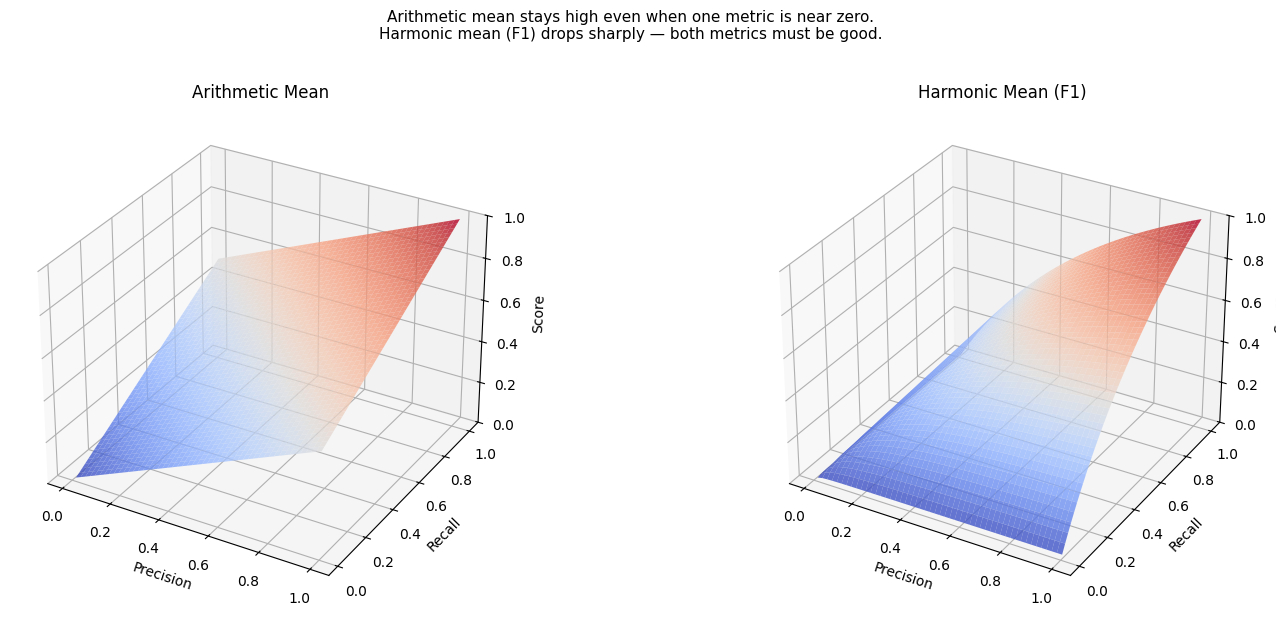

In [8]:
# Why harmonic mean? 3D surface: arithmetic vs harmonic mean
from mpl_toolkits.mplot3d import Axes3D

p = np.linspace(0.01, 1.0, 50)
r = np.linspace(0.01, 1.0, 50)
P, R = np.meshgrid(p, r)

arithmetic = (P + R) / 2
harmonic = 2 * P * R / (P + R)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={"projection": "3d"})

axes[0].plot_surface(P, R, arithmetic, cmap="coolwarm", alpha=0.8)
axes[0].set_xlabel("Precision")
axes[0].set_ylabel("Recall")
axes[0].set_zlabel("Score")
axes[0].set_title("Arithmetic Mean")
axes[0].set_zlim(0, 1)

axes[1].plot_surface(P, R, harmonic, cmap="coolwarm", alpha=0.8)
axes[1].set_xlabel("Precision")
axes[1].set_ylabel("Recall")
axes[1].set_zlabel("Score")
axes[1].set_title("Harmonic Mean (F1)")
axes[1].set_zlim(0, 1)

fig.suptitle("Arithmetic mean stays high even when one metric is near zero.\nHarmonic mean (F1) drops sharply — both metrics must be good.",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [9]:
# Classification report for our model
print("=== Our Model ===")
print(classification_report(df.actual, df.pred, labels=dog_breeds))

=== Our Model ===
                    precision    recall  f1-score   support

Labrador Retriever       0.24      0.33      0.28        64
   German Shepherd       1.00      0.29      0.44        63
  Golden Retriever       0.12      0.27      0.16        49
           Bulldog       1.00      0.48      0.65        58
            Poodle       0.26      0.23      0.24        66

          accuracy                           0.32       300
         macro avg       0.52      0.32      0.36       300
      weighted avg       0.53      0.32      0.36       300



In [10]:
# Compare with baselines
print("=== Majority-Class Baseline ===")
print(classification_report(df.actual, df.pred_majority, labels=dog_breeds, zero_division=0))

print("\n=== Random Baseline ===")
print(classification_report(df.actual, df.pred_random, labels=dog_breeds))

=== Majority-Class Baseline ===
                    precision    recall  f1-score   support

Labrador Retriever       0.00      0.00      0.00        64
   German Shepherd       0.00      0.00      0.00        63
  Golden Retriever       0.00      0.00      0.00        49
           Bulldog       0.00      0.00      0.00        58
            Poodle       0.22      1.00      0.36        66

          accuracy                           0.22       300
         macro avg       0.04      0.20      0.07       300
      weighted avg       0.05      0.22      0.08       300


=== Random Baseline ===
                    precision    recall  f1-score   support

Labrador Retriever       0.24      0.22      0.23        64
   German Shepherd       0.18      0.19      0.19        63
  Golden Retriever       0.19      0.20      0.20        49
           Bulldog       0.16      0.17      0.17        58
            Poodle       0.21      0.20      0.20        66

          accuracy                    

### Macro vs Micro Averaging

Since we compute precision, recall, and F1 *per class*, we need a way to summarize across classes:

1. **Macro-average**; compute the metric for each class, then take the unweighted mean. Every class counts equally regardless of how many examples it has.
2. **Micro-average (weighted)**; weight each class's metric by its support (number of examples). Classes with more examples have more influence.

When classes are balanced, macro ≈ micro. When they are not, the difference reveals whether your model is good at the common classes (micro will be high) or good across all classes (macro will be high).

In [11]:
print("=== Our Model ===")
print(classification_report(df.actual, df.pred, labels=dog_breeds))

=== Our Model ===
                    precision    recall  f1-score   support

Labrador Retriever       0.24      0.33      0.28        64
   German Shepherd       1.00      0.29      0.44        63
  Golden Retriever       0.12      0.27      0.16        49
           Bulldog       1.00      0.48      0.65        58
            Poodle       0.26      0.23      0.24        66

          accuracy                           0.32       300
         macro avg       0.52      0.32      0.36       300
      weighted avg       0.53      0.32      0.36       300



In [12]:
#example calculation of micro vs macro averaged precision
micro_precision = (0.24*64 + 1.*63 + 0.12*49 + 1.*58 + 0.26*66) / (64+63+49+58+66)
macro_precision = (0.24+1.+0.12+1.+0.26)/5

micro_precision, macro_precision

(0.5313333333333333, 0.524)

### Label ImbalanceーWhen Accuracy Stops Functioning

Imagine a medical screening model where 99 % of patients are healthy. A model that always predicts "Healthy" gets 99 % accuracy — but it catches zero sick patients. Accuracy is useless here.

This is why we need precision, recall, and F1. And when classes are imbalanced, **macro-average** is more informative than weighted-average, because it does not let the dominant class inflate the score.

In [13]:
# Imbalanced dataset: 99% Healthy, 1% Diseased
np.random.seed(125)
labels_imb = ["Healthy", "Diseased"]
actuals_imb = np.random.choice(labels_imb, size=300, p=[0.99, 0.01])

df_imb = pd.DataFrame({"actual": actuals_imb, "pred": "Healthy"})

print(f"Class distribution: {dict(zip(*np.unique(actuals_imb, return_counts=True)))}")
print()
print(classification_report(df_imb.actual, df_imb.pred, labels=labels_imb, zero_division=0))

Class distribution: {np.str_('Diseased'): np.int64(3), np.str_('Healthy'): np.int64(297)}

              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99       297
    Diseased       0.00      0.00      0.00         3

    accuracy                           0.99       300
   macro avg       0.49      0.50      0.50       300
weighted avg       0.98      0.99      0.99       300



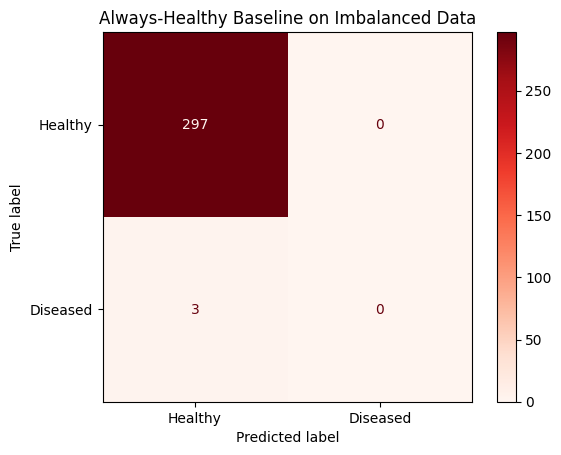

In [14]:
# The confusion matrix makes the problem obvious
ConfusionMatrixDisplay.from_predictions(
    df_imb.actual, df_imb.pred, labels=labels_imb, cmap="Reds"
)
plt.title("Always-Healthy Baseline on Imbalanced Data")
plt.show()

The micro-average F1 is 0.99 — looks great! But the macro-average F1 is 0.50 — revealing that the model completely ignores the minority class. **Always check macro-average when classes are imbalanced.**

### AUROCーArea Under the ROC Curve

So far our metrics depend on a hard decision: the model predicts class A or class B. But many models output a **predicted probability-like score** — e.g., "80% chance this is spam." The cutoff (threshold) you choose to convert probabilities into predictions affects precision and recall.

AUROC evaluates the model across **all possible cutoffs** at once.

The ROC curve plots:
- **X-axis: False Positive Rate (FPR)** — of all actual negatives, how many did the model incorrectly flag as positive?
- **Y-axis: True Positive Rate (Recall)** — of all actual positives, how many did the model catch?

A perfect model hugs the top-left corner (high recall, low FPR). A random model follows the diagonal. The area under this curve (AUROC) ranges from 0.5 (random) to 1.0 (perfect).

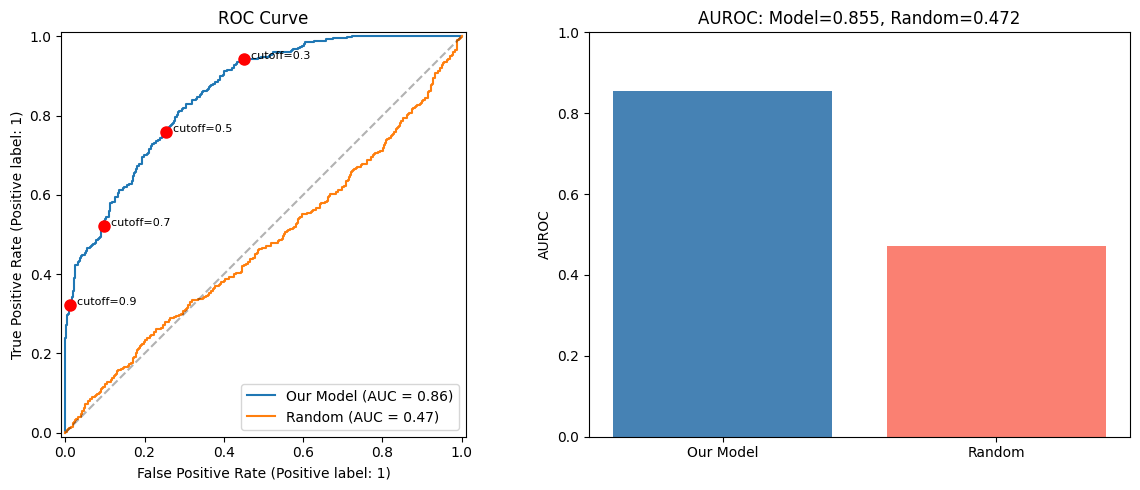

In [15]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Synthetic binary classification with predicted probabilities
num_samples = 1000
np.random.seed(125)

actual_probs = np.random.uniform(0, 1, size=num_samples)
# A decent model: true probability + noise
model_probs = (actual_probs + np.random.uniform(-0.5, 0.5, size=num_samples)).clip(0, 1)
# Random model
np.random.seed(126)
random_probs = np.random.uniform(0, 1, size=num_samples)

actuals_bin = (actual_probs > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(actuals_bin, model_probs, ax=axes[0], name="Our Model")
RocCurveDisplay.from_predictions(actuals_bin, random_probs, ax=axes[0], name="Random")
axes[0].set_title("ROC Curve")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)

# Show the effect of different cutoffs
cutoffs = [0.3, 0.5, 0.7, 0.9]
for cutoff in cutoffs:
    preds = (model_probs >= cutoff).astype(int)
    tp = ((preds == 1) & (actuals_bin == 1)).sum()
    fp = ((preds == 1) & (actuals_bin == 0)).sum()
    fn = ((preds == 0) & (actuals_bin == 1)).sum()
    tn = ((preds == 0) & (actuals_bin == 0)).sum()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    axes[0].plot(fpr_val, tpr_val, "ro", markersize=8)
    axes[0].annotate(f"  cutoff={cutoff}", (fpr_val, tpr_val), fontsize=8)

# AUROC scores
auroc_model = roc_auc_score(actuals_bin, model_probs)
auroc_random = roc_auc_score(actuals_bin, random_probs)
axes[1].bar(["Our Model", "Random"], [auroc_model, auroc_random], color=["steelblue", "salmon"])
axes[1].set_ylabel("AUROC")
axes[1].set_ylim(0, 1)
axes[1].set_title(f"AUROC: Model={auroc_model:.3f}, Random={auroc_random:.3f}")

plt.tight_layout()
plt.show()

**Key insight:** As the cutoff increases, the model becomes more conservative, fewer false positives (lower FPR) but also fewer true positives (lower recall). AUROC captures this entire tradeoff in a single number.

> **When to use AUROC:** When you care about the model's ability to *rank* positive examples above negative ones, regardless of the specific cutoff you will use in production.

### AUPRCーArea Under the Precision-Recall Curve

AUPRC is often used alongside AUROC, especially for **imbalanced datasets**. Instead of FPR vs. Recall, it plots **Precision vs. Recall**.

A common misconception is that AUPRC "fixes" AUROC for imbalanced data. The real difference is subtler: AUPRC is more sensitive to how well the model handles the **high-confidence predictions**, aka the examples where the model is most sure. If your model assigns high probabilities to the positive class and those predictions are correct, AUPRC will be high.

AUROC, by contrast, treats all cutoffs equally. For more detailed explanation, see [this excellent article](https://arxiv.org/pdf/2401.06091).

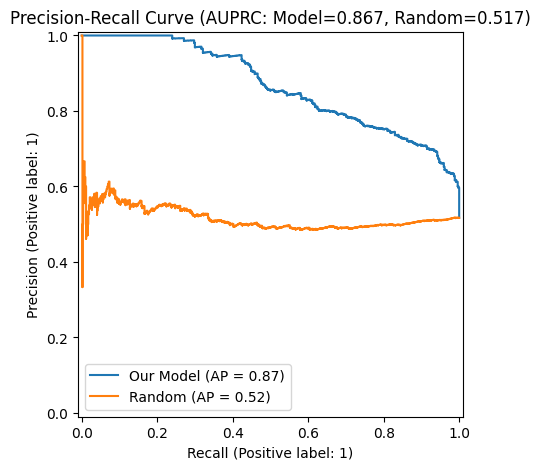

In [16]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(actuals_bin, model_probs, ax=ax, name="Our Model")
PrecisionRecallDisplay.from_predictions(actuals_bin, random_probs, ax=ax, name="Random")

ap_model = average_precision_score(actuals_bin, model_probs)
ap_random = average_precision_score(actuals_bin, random_probs)
ax.set_title(f"Precision-Recall Curve (AUPRC: Model={ap_model:.3f}, Random={ap_random:.3f})")
plt.show()

> **When to use AUPRC:** When the positive class is rare and you care about the quality of the model's top predictions such as in cases of fraud detection, disease screening, anomaly detection.

### AUROC vs. AUPRC — Debunking the Imbalance Misconception

There is a widespread belief that AUROC "breaks" on imbalanced datasets and that AUPRC "fixes" it. **This is not true.** Both metrics work correctly — they just measure different things. Let's prove it with code.

We create two models:
- **Model A** — predicts the true probability ±0.1 (tighter, better)
- **Model B** — predicts the true probability ±0.2 (wider, worse)

We test both on a **2 % prevalence** dataset (imbalanced) and a **50 % prevalence** dataset (balanced). If AUROC breaks under imbalance, it should fail to distinguish Model A from Model B at 2 % prevalence.

> The percentage of positive examples in a dataset is called the **prevalence**.

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score

num_samples = 1000
np.random.seed(125)
actual_probabilities = np.random.uniform(0, 1, size=num_samples)

np.random.seed(126)
model_a_probs = (actual_probabilities + np.random.uniform(-0.1, 0.1, size=num_samples)).clip(0, 1)
np.random.seed(127)
model_b_probs = (actual_probabilities + np.random.uniform(-0.2, 0.2, size=num_samples)).clip(0, 1)

# --- 2% prevalence (imbalanced) ---
actuals_2pct = (actual_probabilities > 0.98).astype(int)

# --- 50% prevalence (balanced) ---
actuals_50pct = (actual_probabilities > 0.50).astype(int)

print("=== AUROC ===")
print(f"  2% prevalence:  Model A = {roc_auc_score(actuals_2pct, model_a_probs):.3f},  Model B = {roc_auc_score(actuals_2pct, model_b_probs):.3f}")
print(f"  50% prevalence: Model A = {roc_auc_score(actuals_50pct, model_a_probs):.3f},  Model B = {roc_auc_score(actuals_50pct, model_b_probs):.3f}")

print("\n=== AUPRC ===")
print(f"  2% prevalence:  Model A = {average_precision_score(actuals_2pct, model_a_probs):.3f},  Model B = {average_precision_score(actuals_2pct, model_b_probs):.3f}")
print(f"  50% prevalence: Model A = {average_precision_score(actuals_50pct, model_a_probs):.3f},  Model B = {average_precision_score(actuals_50pct, model_b_probs):.3f}")

=== AUROC ===
  2% prevalence:  Model A = 0.973,  Model B = 0.944
  50% prevalence: Model A = 0.993,  Model B = 0.970

=== AUPRC ===
  2% prevalence:  Model A = 0.389,  Model B = 0.178
  50% prevalence: Model A = 0.994,  Model B = 0.974


**Observation:** AUROC correctly ranks Model A above Model B in both cases. It does NOT break under imbalance. The gap between models is similar regardless of prevalence.

AUPRC also correctly ranks Model A above Model B, but the *absolute values* change dramatically: from ~0.99 at 50 % prevalence to ~0.39 at 2 % prevalence. This is what makes people think AUPRC is "more sensitive" to imbalance, but it is actually sensitive to something else entirely.

### What AUPRC Actually Measures

AUPRC is sensitive to **how well the model handles its high-confidence predictions**, aka the examples where the model assigns the highest probabilities.

In our 2% prevalence dataset, positive examples have true probabilities > 0.98. Since our models predict true probability ± noise, the positive examples naturally get high predicted probabilities. AUPRC rewards this clustering of positives at the top of the ranking.

But what if positive examples are *not* clustered at high predicted probabilities? Let's test: we create a dataset where positives are scattered across the probability range (true probabilities around 0.7, 0.8, and 0.9 — not just > 0.98).

In [43]:
# Positives scattered across the probability range (not clustered at the top)
actuals_scattered = (
    ((actual_probabilities > 0.70) & (actual_probabilities < 0.71)) |
    ((actual_probabilities > 0.80) & (actual_probabilities < 0.81)) |
    ((actual_probabilities > 0.90) & (actual_probabilities < 0.91))
).astype(int)

print(f"Prevalence: {actuals_scattered.mean():.1%}")
print()

print("=== Scattered positives (predicted probabilities spread out) ===")
print(f"  AUROC:  Model A = {roc_auc_score(actuals_scattered, model_a_probs):.4f},  Model B = {roc_auc_score(actuals_scattered, model_b_probs):.4f}")
print(f"  AUPRC:  Model A = {average_precision_score(actuals_scattered, model_a_probs):.4f},  Model B = {average_precision_score(actuals_scattered, model_b_probs):.4f}")

print()
print("=== Clustered positives (predicted probabilities all high, from before) ===")
print(f"  AUROC:  Model A = {roc_auc_score(actuals_2pct, model_a_probs):.4f},  Model B = {roc_auc_score(actuals_2pct, model_b_probs):.4f}")
print(f"  AUPRC:  Model A = {average_precision_score(actuals_2pct, model_a_probs):.4f},  Model B = {average_precision_score(actuals_2pct, model_b_probs):.4f}")

Prevalence: 2.4%

=== Scattered positives (predicted probabilities spread out) ===
  AUROC:  Model A = 0.8394,  Model B = 0.8346
  AUPRC:  Model A = 0.0719,  Model B = 0.0716

=== Clustered positives (predicted probabilities all high, from before) ===
  AUROC:  Model A = 0.9728,  Model B = 0.9435
  AUPRC:  Model A = 0.3887,  Model B = 0.1785


**Key insight:** Even at similar prevalence (~2%), the AUPRC gap between models is much smaller (almost non-existent) when positives are scattered across the probability range. The large AUPRC gap we saw earlier was not caused by imbalance; it was caused by positives being clustered at high predicted probabilities. In short,

- **AUROC** treats all cutoffs equally. It tells you how well the model ranks positives above negatives overall. It works fine under imbalance.
- **AUPRC** is sensitive to the model's high-confidence predictions. It tells you how precise the model is when it is most confident. The absolute value changes with prevalence, but this is not a flaw; it reflects a different question.
- The misconception arises because in many real-world imbalanced datasets, rare positive examples *do* get high predicted probabilities, making AUPRC appear to "detect" imbalance. But it is detecting prediction clustering, not prevalence.

## 3. Regression Metrics

Regression predicts a **continuous number** — house prices, temperature, stock returns. The evaluation mindset is different from classification: instead of "right or wrong," we measure "how far off."

### Always Plot FirstーAnscombe's Quartet

Before computing any metric, **plot your data**. Anscombe's quartet is the classic demonstration of why: four datasets with nearly identical summary statistics (same mean, variance, correlation, and regression line) that look completely different when plotted.

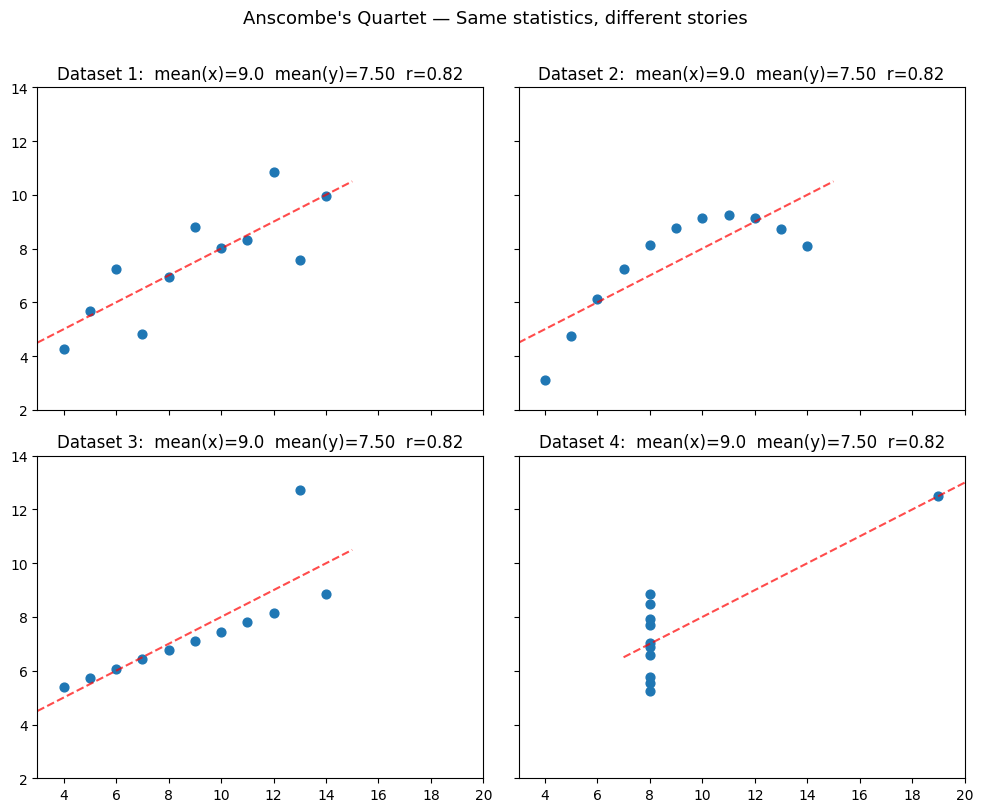

In [19]:
# Anscombe's quartet — same statistics, wildly different data
anscombe = pd.DataFrame({
    "x1": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    "y1": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    "x2": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    "y2": [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    "x3": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    "y3": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    "x4": [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
    "y4": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
})

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat, 1):
    x, y = anscombe[f"x{i}"], anscombe[f"y{i}"]
    ax.scatter(x, y, s=40)
    # Fit and plot regression line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min() - 1, x.max() + 1, 100)
    ax.plot(x_line, m * x_line + b, "r--", alpha=0.7)
    ax.set_title(f"Dataset {i}:  mean(x)={x.mean():.1f}  mean(y)={y.mean():.2f}  r={x.corr(y):.2f}")
    ax.set_xlim(3, 20)
    ax.set_ylim(2, 14)

fig.suptitle("Anscombe\'s Quartet — Same statistics, different stories", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

All four datasets have nearly the same mean of x (~9), mean of y (~7.5), correlation (~0.82), and regression line. But:

- **Dataset 1** — a normal linear relationship. Metrics work fine here.
- **Dataset 2** — a clear non-linear pattern. A linear model is wrong, but MSE/MAE would not tell you that.
- **Dataset 3** — one outlier pulls the regression line. The outlier dominates MSE.
- **Dataset 4** — one extreme x-value creates a misleading correlation. Remove it and the relationship disappears.

The lesson: **no single metric can replace looking at your data.** Always plot actual vs. predicted before trusting any number.

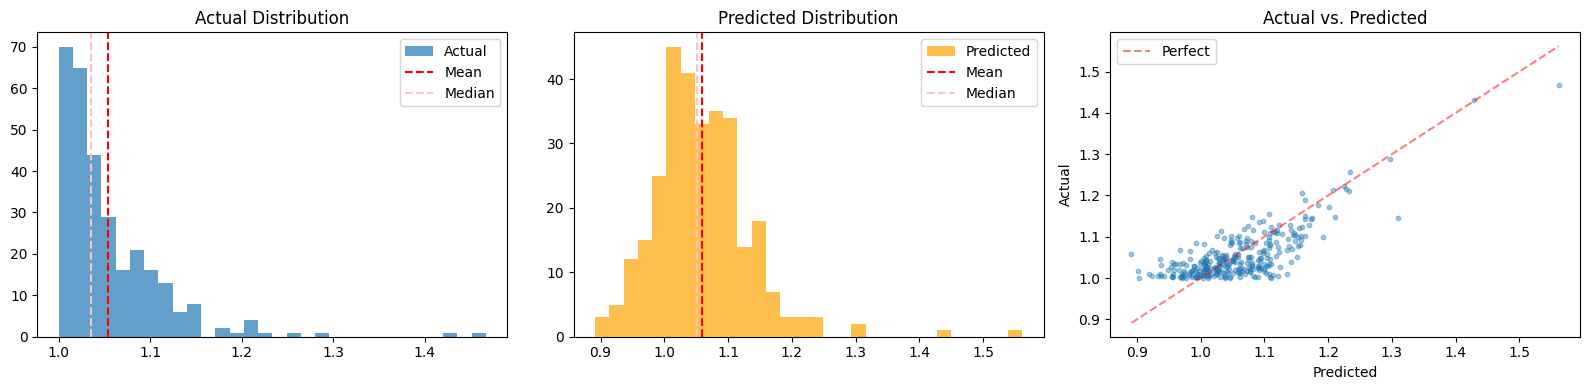

In [20]:
# Synthetic regression data with a power-law distribution
np.random.seed(125)
num_samples = 300

alpha = 20.0
xmin = 1.0
actual_values = (np.random.pareto(alpha, num_samples) + 1) * xmin
pred_values = actual_values + np.random.normal(0, 0.05, num_samples)

df_reg = pd.DataFrame({"actual": actual_values, "pred": pred_values})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution of actuals
axes[0].hist(df_reg.actual, bins=30, alpha=0.7, label="Actual")
axes[0].axvline(df_reg.actual.mean(), color="red", linestyle="--", label="Mean")
axes[0].axvline(df_reg.actual.median(), color="pink", linestyle="--", label="Median")
axes[0].legend()
axes[0].set_title("Actual Distribution")

# Distribution of predictions
axes[1].hist(df_reg.pred, bins=30, alpha=0.7, color="orange", label="Predicted")
axes[1].axvline(df_reg.pred.mean(), color="red", linestyle="--", label="Mean")
axes[1].axvline(df_reg.pred.median(), color="pink", linestyle="--", label="Median")
axes[1].legend()
axes[1].set_title("Predicted Distribution")

# Scatter: actual vs predicted
axes[2].scatter(df_reg.pred, df_reg.actual, alpha=0.4, s=10)
min_val = min(df_reg.actual.min(), df_reg.pred.min())
max_val = max(df_reg.actual.max(), df_reg.pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], "r--", alpha=0.5, label="Perfect")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].legend()
axes[2].set_title("Actual vs. Predicted")

plt.tight_layout()
plt.show()

In [71]:
df_reg.head()

,actual,pred
0,1.035966,1.080678
1,1.002967,1.029749
2,1.050626,1.073544
3,1.007135,1.113163
4,1.007050,1.010675


### MSE, MAE, ~~MAPE~~ (What to Use Instead), and Percentage Within Tolerance

| Metric | Formula | Behavior |
|---|---|---|
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Penalizes large errors heavily (squared). Sensitive to outliers. |
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum\lvert y_i - \hat{y}_i \rvert$ | Treats all errors linearly. More robust to outliers. |
| **MAPE** (Mean Absolute Percentage Error) | $\frac{1}{n}\sum\lvert\frac{y_i - \hat{y}_i}{y_i}\rvert$ | Shows error as a percentage. Has serious flaws (see below). |
| **Percentage Within Tolerance** | $\frac{1}{n}\sum\mathbb{1}\left[\lvert\frac{y_i - \hat{y}_i}{y_i}\rvert \leq t\right]$ | Fraction of predictions within ±t% of actual. Intuitive and directly actionable. |

In [86]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def pct_within_tolerance(y_true, y_pred, tolerance=0.10):
    """Fraction of predictions within ±tolerance of actual values."""
    return np.mean(np.abs((y_true - y_pred) / y_true) <= tolerance) * 100

# --- Our model vs. baselines ---
mean_baseline = np.full(num_samples, df_reg.actual.mean())
median_baseline = np.full(num_samples, df_reg.actual.median())

results = []
for name, preds in [("Our Model", df_reg.pred), ("Mean Baseline", mean_baseline), ("Median Baseline", median_baseline)]:
    results.append({
        "Model": name,
        "MSE": mean_squared_error(df_reg.actual, preds),
        "MAE": mean_absolute_error(df_reg.actual, preds),
        "MAPE (%)": mean_absolute_percentage_error(df_reg.actual, preds),
        "Within ±10%": f"{pct_within_tolerance(df_reg.actual, preds, 0.10):.1f}%",
        "Within ±5%": f"{pct_within_tolerance(df_reg.actual, preds, 0.05):.1f}%",
    })

pd.DataFrame(results).set_index("Model")

,MSE,MAE,MAPE (%),Within ±10%,Within ±5%
Model,,,,,
Our Model,0.002377,0.038609,3.681419,97.0%,72.3%
Mean Baseline,0.003456,0.040809,3.747360,96.0%,79.7%
Median Baseline,0.003786,0.037839,3.402513,95.7%,80.7%


Text(0.5, 1.0, 'Actual vs. Predicted')

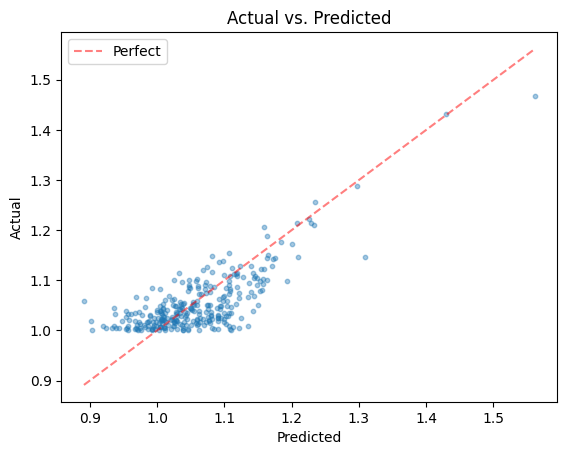

In [91]:
fig, axes = plt.subplots(1, 1)
axes.scatter(df_reg.pred, df_reg.actual, alpha=0.4, s=10)
min_val = min(df_reg.actual.min(), df_reg.pred.min())
max_val = max(df_reg.actual.max(), df_reg.pred.max())
axes.plot([min_val, max_val], [min_val, max_val], "r--", alpha=0.5, label="Perfect")
axes.set_xlabel("Predicted")
axes.set_ylabel("Actual")
axes.legend()
axes.set_title("Actual vs. Predicted")

#### Why MAPE Is Problematic

MAPE has three flaws:

1. **Asymmetry**; it disproportionately penalizes over-prediction. Because the actual value $y_i$ is in the denominator, over-prediction and under-prediction by the same *multiplicative factor* get different MAPE scores. Predicting 2× the actual gives 100% MAPE, but predicting 0.5× the actual gives only 50%. A model that minimizes MAPE will learn to systematically under-predict.

2. **Undefined at zero**; it cannot be computed when $y_i = 0$. Division by zero makes MAPE blow up entirely.

3. **Explodes near zero**; even small actuals cause extreme values. A prediction of 0.2 when the actual is 0.1 gives 100% MAPE, while a prediction of 100.1 when the actual is 100.0 gives only 0.1%, even though both are off by the same absolute amount.

In [87]:
# --- MAPE's three flaws ---

# Flaw 1: Asymmetry — same multiplicative error, different MAPE
# Predicting 2× actual and 0.5× actual are the same "multiplicative distance"
# from the truth. But MAPE treats them differently.

actual = np.array([100.0])

print("=== Flaw 1: Asymmetry ===")
print("Same multiplicative error in opposite directions:")
print(f"  Actual = 100")
print(f"  Pred = 200 (2× actual):   MAPE = {mean_absolute_percentage_error(actual, np.array([200.0])):.0f}%")
print(f"  Pred =  50 (0.5× actual): MAPE = {mean_absolute_percentage_error(actual, np.array([50.0])):.0f}%")
print()
print(f"  Pred = 300 (3× actual):   MAPE = {mean_absolute_percentage_error(actual, np.array([300.0])):.0f}%")
print(f"  Pred =  33 (⅓× actual):   MAPE = {mean_absolute_percentage_error(actual, np.array([33.33])):.0f}%")
print()
print("Over-prediction by 2× gives 100%, but under-prediction by 2× gives only 50%.")
print("MAPE systematically penalizes over-prediction more. A model that")
print("minimizes MAPE will learn to under-predict.")
print()

# Flaw 2: Undefined at zero
print("=== Flaw 2: Undefined at zero ===")
y_true_zero = np.array([100.0, 0.0, 50.0])
y_pred_zero = np.array([110.0, 5.0, 45.0])
print(f"Actuals: {y_true_zero}  (contains a zero)")
print(f"MAPE = {mean_absolute_percentage_error(y_true_zero, y_pred_zero):.1f}%  ← inf because of division by zero")
print()

# Flaw 3: Explodes near zero
print("=== Flaw 3: Explodes near zero ===")
y_true_small = np.array([0.1, 0.1, 0.1])
y_pred_small = np.array([0.2, 0.2, 0.2])   # off by 0.1
y_true_big   = np.array([100.0, 100.0, 100.0])
y_pred_big   = np.array([100.1, 100.1, 100.1])  # also off by 0.1

print(f"Actual=0.1, Pred=0.2 (off by 0.1): MAPE = {mean_absolute_percentage_error(y_true_small, y_pred_small):.0f}%")
print(f"Actual=100, Pred=100.1 (off by 0.1): MAPE = {mean_absolute_percentage_error(y_true_big, y_pred_big):.1f}%")
print("Same absolute error (0.1), wildly different MAPE (100% vs 0.1%).")

=== Flaw 1: Asymmetry ===
Same multiplicative error in opposite directions:
  Actual = 100
  Pred = 200 (2× actual):   MAPE = 100%
  Pred =  50 (0.5× actual): MAPE = 50%

  Pred = 300 (3× actual):   MAPE = 200%
  Pred =  33 (⅓× actual):   MAPE = 67%

Over-prediction by 2× gives 100%, but under-prediction by 2× gives only 50%.
MAPE systematically penalizes over-prediction more. A model that
minimizes MAPE will learn to under-predict.

=== Flaw 2: Undefined at zero ===
Actuals: [100.   0.  50.]  (contains a zero)
MAPE = inf%  ← inf because of division by zero

=== Flaw 3: Explodes near zero ===
Actual=0.1, Pred=0.2 (off by 0.1): MAPE = 100%
Actual=100, Pred=100.1 (off by 0.1): MAPE = 0.1%
Same absolute error (0.1), wildly different MAPE (100% vs 0.1%).


/var/folders/g_/n0dkqd3s5js28y5hb238xs1r0000gq/T/ipykernel_63055/3019463067.py:4: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


#### Alternatives to MAPE

No single alternative truly fixes all three problems. Our recommendation is to use non-percentage-based metrics such as MASE and percentage within tolerance.

| Metric | Fixes asymmetry? | Fixes division by zero? | Fixes near-zero explosion? |
|---|---|---|---|
| **MAPE** | ✗ | ✗ | ✗ |
| **sMAPE** $\frac{1}{n}\sum\frac{\lvert y_i - \hat{y}_i \rvert}{(\lvert y_i \rvert + \lvert \hat{y}_i \rvert)/2}$ | ✓ | ✗ (0/0 when both are zero) | ✗ |
| **WAPE** $\frac{\sum\lvert y_i - \hat{y}_i \rvert}{\sum\lvert y_i \rvert}$ | ✗ | ✓ (divides by sum, not per-sample) | ✗ |
| **MASE** $\frac{\text{MAE of model}}{\text{MAE of naive lag-1}}$ | ✓ | ✓ | ✓ |
| **% within Tolerance** | ✓ | ✓ | ✓ |

**MASE** avoids all three pitfalls because it is not a percentage metric at all; it scales by the naive baseline's error instead of by the actual values. The tradeoff is that MASE requires time series data (it needs a lag-1 baseline) or a baseline prediction to compare to.

**Percentage within tolerance** is another escape hatch: it asks *what fraction of predictions are close enough?* and avoids all percentage-error pitfalls. You set the tolerance based on what matters for your application such as  ±5 % for pricing, ±20 % for demand forecasting.

In [88]:
# --- sMAPE and WAPE: how do they handle the same situations? ---

def symmetric_mape(y_true, y_pred):
    """sMAPE: uses average of actual and predicted in denominator."""
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    return np.mean(numerator[mask] / denominator[mask]) * 100 if mask.any() else 0.0

def weighted_absolute_percentage_error(y_true, y_pred):
    """WAPE: one ratio over the whole dataset. No per-sample division."""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def mean_absolute_scaled_error(y_true, y_pred, y_train):
    """MASE: MAE of model / MAE of naive lag-1 on training set.
    MASE < 1 means the model beats the naive baseline."""
    mae_model = np.mean(np.abs(y_true - y_pred))
    mae_naive = np.mean(np.abs(np.diff(y_train)))
    return mae_model / mae_naive if mae_naive > 0 else np.inf

# --- Flaw 1 revisited: Asymmetry ---
actual = np.array([100.0])

print("=== Flaw 1 revisited: Asymmetry ===")
print(f"{'Scenario':<30} {'MAPE':>8} {'sMAPE':>8} {'WAPE':>8}")
print("-" * 56)
for name, pred in [
    ("Pred=200 (2× actual)",   np.array([200.0])),
    ("Pred= 50 (0.5× actual)", np.array([ 50.0])),
    ("Pred=300 (3× actual)",   np.array([300.0])),
    ("Pred= 33 (⅓× actual)",   np.array([ 33.33])),
]:
    m = mean_absolute_percentage_error(actual, pred)
    s = symmetric_mape(actual, pred)
    w = weighted_absolute_percentage_error(actual, pred)
    print(f"{name:<30} {m:>7.0f}% {s:>7.1f}% {w:>7.0f}%")

print()
print("sMAPE fixes asymmetry: 66.7% for both 2× and 0.5×, 100% for both 3× and ⅓×.")
print("WAPE does NOT fix asymmetry — same values as MAPE here.")

# --- Flaw 2 revisited: Division by zero ---
print()
print("=== Flaw 2 revisited: Division by zero ===")
y_true_with_zero = np.array([100.0, 0.0, 50.0])
y_pred_with_zero = np.array([110.0, 5.0, 45.0])

print(f"Actuals contain a zero: {y_true_with_zero}")
try:
    m = mean_absolute_percentage_error(y_true_with_zero, y_pred_with_zero)
    print(f"MAPE:  {m:.1f}% (inf or nan — division by zero)")
except:
    print("MAPE:  crashed (division by zero)")
print(f"sMAPE: {symmetric_mape(y_true_with_zero, y_pred_with_zero):.1f}% (skips 0/0 but still per-sample)")
print(f"WAPE:  {weighted_absolute_percentage_error(y_true_with_zero, y_pred_with_zero):.1f}% (divides by sum=150, no per-sample issue)")

# --- Flaw 3 revisited: Near-zero explosion ---
print()
print("=== Flaw 3 revisited: Near-zero explosion ===")
y_true_small = np.array([0.1, 0.1, 0.1])
y_pred_small = np.array([0.2, 0.2, 0.2])
y_true_big   = np.array([100.0, 100.0, 100.0])
y_pred_big   = np.array([100.1, 100.1, 100.1])

print(f"{'Scenario':<30} {'MAPE':>8} {'sMAPE':>8} {'WAPE':>8}")
print("-" * 56)
print(f"{'Actual=0.1, Pred=0.2':<30} {mean_absolute_percentage_error(y_true_small, y_pred_small):>7.0f}% {symmetric_mape(y_true_small, y_pred_small):>7.1f}% {weighted_absolute_percentage_error(y_true_small, y_pred_small):>7.0f}%")
print(f"{'Actual=100, Pred=100.1':<30} {mean_absolute_percentage_error(y_true_big, y_pred_big):>7.1f}% {symmetric_mape(y_true_big, y_pred_big):>7.1f}% {weighted_absolute_percentage_error(y_true_big, y_pred_big):>7.1f}%")
print()
print("None of them fix the near-zero explosion. All percentage-based metrics")
print("struggle here. Use MAE, MASE, or percentage-within-tolerance instead.")

=== Flaw 1 revisited: Asymmetry ===
Scenario                           MAPE    sMAPE     WAPE
--------------------------------------------------------
Pred=200 (2× actual)               100%    66.7%     100%
Pred= 50 (0.5× actual)              50%    66.7%      50%
Pred=300 (3× actual)               200%   100.0%     200%
Pred= 33 (⅓× actual)                67%   100.0%      67%

sMAPE fixes asymmetry: 66.7% for both 2× and 0.5×, 100% for both 3× and ⅓×.
WAPE does NOT fix asymmetry — same values as MAPE here.

=== Flaw 2 revisited: Division by zero ===
Actuals contain a zero: [100.   0.  50.]
MAPE:  inf% (inf or nan — division by zero)
sMAPE: 73.4% (skips 0/0 but still per-sample)
WAPE:  13.3% (divides by sum=150, no per-sample issue)

=== Flaw 3 revisited: Near-zero explosion ===
Scenario                           MAPE    sMAPE     WAPE
--------------------------------------------------------
Actual=0.1, Pred=0.2               100%    66.7%     100%
Actual=100, Pred=100.1            

/var/folders/g_/n0dkqd3s5js28y5hb238xs1r0000gq/T/ipykernel_63055/3019463067.py:4: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


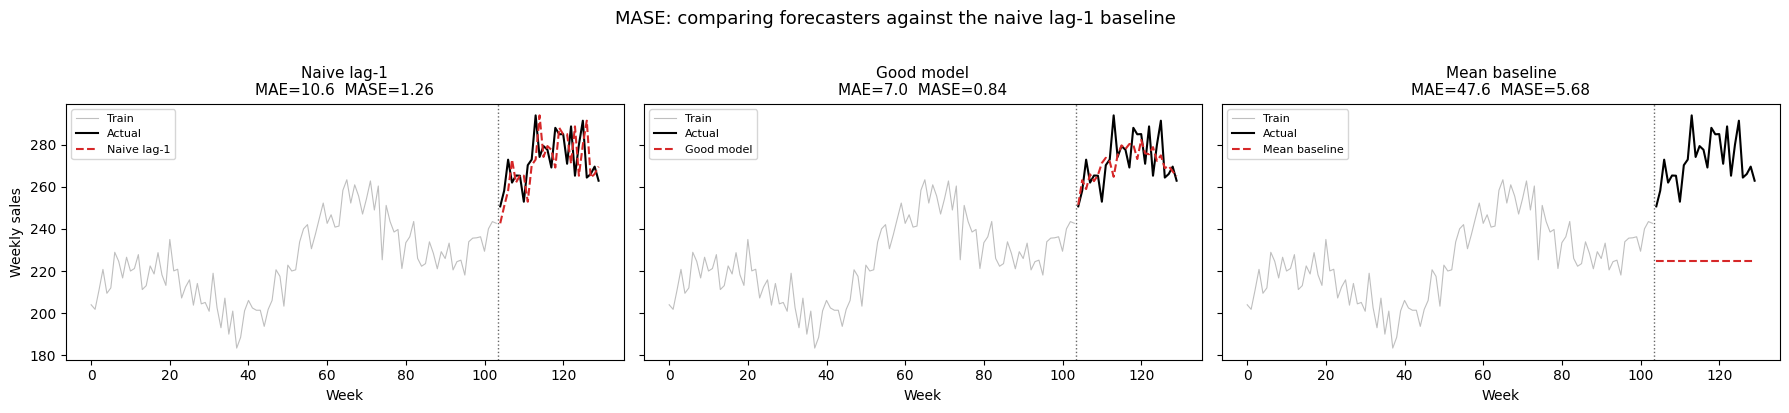

MASE denominator (training naive lag-1 MAE): 8.38

--------------------------------------------------------------
Naive lag-1            10.59     3.9%     3.9%    1.26
Good model              7.02     2.5%     2.6%    0.84
Mean baseline          47.65    17.4%    19.1%    5.68

MASE ≈ 1 for naive lag-1 (not exactly 1.0 because the denominator is
computed on training data, and test-set volatility may differ slightly).
MASE < 1 → model beats the naive baseline. Good.
MASE > 1 → model is worse than just predicting 'same as last week'. Bad.


In [89]:
# --- MASE demo: time series context ---
# MASE only makes sense for time series because it compares against a naive lag-1 forecast.
# Denominator = naive lag-1 MAE computed on the TRAINING set.
# So MASE ≈ 1.0 for naive on test (not exactly 1.0, since test volatility may differ).

np.random.seed(42)

# 2 years of weekly sales: trend + seasonality + noise
weeks_train = 104
t_train = np.arange(weeks_train)
train_sales = (200 + 0.5 * t_train
               + 20 * np.sin(2 * np.pi * t_train / 52)
               + np.random.normal(0, 8, weeks_train))

# Test: next 26 weeks, same pattern continues
weeks_test = 26
t_test = np.arange(weeks_train, weeks_train + weeks_test)
test_actual = (200 + 0.5 * t_test
               + 20 * np.sin(2 * np.pi * t_test / 52)
               + np.random.normal(0, 8, weeks_test))

# Three forecasters:
naive_pred = np.concatenate([[train_sales[-1]], test_actual[:-1]])
np.random.seed(99)
good_pred = (200 + 0.5 * t_test
             + 20 * np.sin(2 * np.pi * t_test / 52)
             + np.random.normal(0, 4, weeks_test))
bad_pred = np.full(weeks_test, train_sales.mean())

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, pred) in zip(axes, [("Naive lag-1", naive_pred), ("Good model", good_pred), ("Mean baseline", bad_pred)]):
    mase = mean_absolute_scaled_error(test_actual, pred, train_sales)
    mae = mean_absolute_error(test_actual, pred)

    # Training data in gray
    ax.plot(t_train, train_sales, color="0.75", linewidth=0.8, label="Train")
    # Test actual
    ax.plot(t_test, test_actual, color="black", linewidth=1.5, label="Actual")
    # Forecast
    ax.plot(t_test, pred, color="tab:red", linewidth=1.5, linestyle="--", label=name)

    ax.set_title(f"{name}\nMAE={mae:.1f}  MASE={mase:.2f}", fontsize=11)
    ax.set_xlabel("Week")
    ax.legend(fontsize=8, loc="upper left")
    ax.axvline(weeks_train - 0.5, color="0.4", linestyle=":", linewidth=1)

axes[0].set_ylabel("Weekly sales")
plt.suptitle("MASE: comparing forecasters against the naive lag-1 baseline", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Table ---
print(f"MASE denominator (training naive lag-1 MAE): {np.mean(np.abs(np.diff(train_sales))):.2f}")
print()
print("-" * 62)

for name, pred in [("Naive lag-1", naive_pred), ("Good model", good_pred), ("Mean baseline", bad_pred)]:
    mae = mean_absolute_error(test_actual, pred)
    mape = mean_absolute_percentage_error(test_actual, pred)
    smape = symmetric_mape(test_actual, pred)
    mase = mean_absolute_scaled_error(test_actual, pred, train_sales)
    print(f"{name:<20} {mae:>7.2f} {mape:>7.1f}% {smape:>7.1f}% {mase:>7.2f}")

print()
print("MASE ≈ 1 for naive lag-1 (not exactly 1.0 because the denominator is")
print("computed on training data, and test-set volatility may differ slightly).")
print("MASE < 1 → model beats the naive baseline. Good.")
print("MASE > 1 → model is worse than just predicting 'same as last week'. Bad.")

In [90]:
# Percentage within tolerance at different thresholds; most actionable
tolerances = [0.01, 0.02, 0.05, 0.10, 0.20]
for t in tolerances:
    pct = pct_within_tolerance(df_reg.actual, df_reg.pred, tolerance=t)
    print(f"Within ±{t:4.0%}: {pct:5.1f}% of predictions")

print("This is directly actionable: if your business needs 90% of predictions")
print("within ±5%, you can read the answer straight from this table.")

Within ±  1%:  19.0% of predictions
Within ±  2%:  33.7% of predictions
Within ±  5%:  72.3% of predictions
Within ± 10%:  97.0% of predictions
Within ± 20%: 100.0% of predictions
This is directly actionable: if your business needs 90% of predictions
within ±5%, you can read the answer straight from this table.


### Regression Baselines

1. **Mean baseline**; always predict the mean of the training set. This is the optimal constant prediction under MSE.
2. **Median baseline**; always predict the median. Optimal under MAE, and more robust when the distribution is skewed.
3. **Lag-N values**; for time series predictions, predicting that the current snapshot will be the same as the previous N sanpshot (usually N=1) is surprisingly a very strong baseline. Think about if someone asks how many bottles of water will a supermarket sell this week. Chances are `same as last week` is one of the more accurate answer.

If your model cannot beat the mean/median/lag-N-value baseline, it has not learned any useful patterns from the features.

## 4. Information Retrieval / Ranking Metrics

Most real-world ML systems are ranking problems: search engines rank web pages, recommendation systems rank products, and RAG pipelines rank retrieved documents. The question is not "is this prediction correct?" but "are the top-k results relevant?"

We will use a toy anime recommendation dataset: 50 users, 20 anime titles. The model outputs a predicted probability that each user will watch each anime.

In [24]:
# --- Synthetic anime recommendation dataset ---
anime_names = [
    "Attack on Titan", "One Piece", "Naruto", "Death Note",
    "Fullmetal Alchemist", "Sword Art Online", "My Hero Academia",
    "Tokyo Ghoul", "Hunter x Hunter", "Dragon Ball Z",
    "Cowboy Bebop", "Steins;Gate", "Neon Genesis Evangelion",
    "Fairy Tail", "Demon Slayer", "Code Geass",
    "One Punch Man", "Bleach", "The Promised Neverland", "Black Clover",
]

num_users = 50
num_anime = 20

# Predicted probabilities (model scores)
np.random.seed(0)
user_item_prob = np.random.randint(0, 101, size=(num_users, num_anime)) / 101

# Ground truth: each user watched 1-9 random anime
outcome = np.zeros((num_users, num_anime))
np.random.seed(11)
for i in range(num_users):
    n_watched = np.random.randint(1, 10)
    watched_idx = np.random.choice(num_anime, size=n_watched, replace=False)
    outcome[i, watched_idx] = 1

print(f"Users: {num_users}, Anime: {num_anime}")
print(f"Avg anime watched per user: {outcome.sum(axis=1).mean():.1f}")

# Convert to a long-format DataFrame for easier manipulation
rows = []
for uid in range(num_users):
    for aid in range(num_anime):
        rows.append({"user_id": uid, "anime_id": aid, "anime": anime_names[aid],
                      "score": user_item_prob[uid, aid], "watched": int(outcome[uid, aid])})
df_ir = pd.DataFrame(rows)

# Rank anime per user by predicted score (descending)
df_ir["rank"] = df_ir.groupby("user_id")["score"].rank(method="first", ascending=False).astype(int)
df_ir = df_ir.sort_values(["user_id", "rank"])
df_ir[df_ir.user_id == 0].head(10)

Users: 50, Anime: 20
Avg anime watched per user: 4.6


,user_id,anime_id,anime,score,watched,rank
11,0,11,Steins;Gate,0.871287,0,1
12,0,12,Neon Genesis Evangelion,0.871287,0,2
19,0,19,Black Clover,0.871287,0,3
9,0,9,Dragon Ball Z,0.861386,0,4
17,0,17,Bleach,0.861386,0,5
6,0,6,My Hero Academia,0.821782,0,6
10,0,10,Cowboy Bebop,0.693069,0,7
3,0,3,Death Note,0.663366,1,8
4,0,4,Fullmetal Alchemist,0.663366,0,9
15,0,15,Code Geass,0.643564,0,10


### Precision@k and Recall@k

**Precision@k** — of the top-k recommended items, how many are relevant?

$$\text{Precision@k} = \frac{\text{relevant items in top-k}}{k}$$

**Recall@k** — of all relevant items, how many appear in the top-k?

$$\text{Recall@k} = \frac{\text{relevant items in top-k}}{\text{total relevant items}}$$

In [25]:
def precision_at_k(y_true, y_score, k=5):
    """Average precision@k across all users."""
    top_k = np.argsort(-y_score, axis=1)[:, :k]
    hits = np.array([y_true[i, top_k[i]].sum() for i in range(len(y_true))])
    return (hits / k).mean()

def recall_at_k(y_true, y_score, k=5):
    """Average recall@k across all users."""
    top_k = np.argsort(-y_score, axis=1)[:, :k]
    hits = np.array([y_true[i, top_k[i]].sum() for i in range(len(y_true))])
    totals = y_true.sum(axis=1)
    # Avoid division by zero for users with no relevant items
    return np.mean(hits / np.maximum(totals, 1))

for k in [1, 3, 5, 10]:
    p = precision_at_k(outcome, user_item_prob, k=k)
    r = recall_at_k(outcome, user_item_prob, k=k)
    print(f"k={k:2d}  Precision@k={p:.3f}  Recall@k={r:.3f}")

k= 1  Precision@k=0.220  Recall@k=0.031
k= 3  Precision@k=0.200  Recall@k=0.106
k= 5  Precision@k=0.216  Recall@k=0.200
k=10  Precision@k=0.226  Recall@k=0.498


### Mean Average Precision (mAP)

Precision@k depends on the choice of k. **Average Precision (AP)** summarizes across all k values by averaging precision@k only at positions where a relevant item appears. This rewards models that place relevant items higher in the ranking.

**mAP** is the mean of AP across all users.

$$\text{AP} = \frac{1}{|\text{relevant}|} \sum_{k=1}^{N} \text{Precision@k} \cdot \mathbb{1}[\text{item}_k \text{ is relevant}]$$

In [26]:
def average_precision(y_true_user, y_score_user):
    """AP for a single user."""
    order = np.argsort(-y_score_user)
    y_sorted = y_true_user[order]
    n_relevant = y_sorted.sum()
    if n_relevant == 0:
        return 0.0
    cumsum = np.cumsum(y_sorted)
    precisions = cumsum / np.arange(1, len(y_sorted) + 1)
    return (precisions * y_sorted).sum() / n_relevant

def mean_average_precision(y_true, y_score):
    """mAP across all users."""
    return np.mean([average_precision(y_true[i], y_score[i]) for i in range(len(y_true))])

print(f"mAP = {mean_average_precision(outcome, user_item_prob):.4f}")

# Show AP for a few individual users
for uid in [0, 3, 5]:
    ap = average_precision(outcome[uid], user_item_prob[uid])
    print(f"  User {uid}: AP = {ap:.4f}")

mAP = 0.3082
  User 0: AP = 0.1250
  User 3: AP = 0.0911
  User 5: AP = 0.3097


### Mean Reciprocal Rank (MRR)

MRR cares about one thing: **how high is the first relevant item?**

For each user, the reciprocal rank is $1 / \text{rank of first relevant item}$. MRR is the average across users.

- First relevant item at rank 1 → score = 1.0
- First relevant item at rank 5 → score = 0.2
- No relevant item → score = 0.0

MRR is useful when you only care about the single best result (e.g., "I'm feeling lucky" search).

In [27]:
def mean_reciprocal_rank(y_true, y_score):
    rrs = []
    for i in range(len(y_true)):
        order = np.argsort(-y_score[i])
        ranked = y_true[i][order]
        relevant_positions = np.where(ranked == 1)[0]
        if len(relevant_positions) > 0:
            rrs.append(1.0 / (relevant_positions[0] + 1))
        else:
            rrs.append(0.0)
    return np.mean(rrs)

print(f"MRR = {mean_reciprocal_rank(outcome, user_item_prob):.4f}")

# Show individual examples
for uid in [3, 4, 5]:
    order = np.argsort(-user_item_prob[uid])
    ranked_watched = outcome[uid][order]
    first_hit = np.where(ranked_watched == 1)[0][0] + 1
    print(f"  User {uid}: first relevant item at rank {first_hit} → RR = {1/first_hit:.4f}")

MRR = 0.3949
  User 3: first relevant item at rank 13 → RR = 0.0769
  User 4: first relevant item at rank 9 → RR = 0.1111
  User 5: first relevant item at rank 3 → RR = 0.3333


### Information Retrieval Baselines

Just like classification and regression, ranking models need baselines:

1. **Random baseline**; rank items in random order. If your model cannot beat random, it has learned nothing about user preferences.
2. **Popularity baseline**; always recommend the most globally popular items (most watched, most clicked, most purchased). This is a surprisingly strong baseline; popular items are popular for a reason. Many production systems struggle to beat it for new users with no history.

If your model beats random but not popularity, it means the model has not learned anything beyond "recommend what everyone likes". The real value of a recommendation system is **personalization**, surfacing items that are relevant to *this specific user*, not just popular in general.


### Bridge to RAG Evaluation

These same metricsーprecision@k, recall@k, mAP, MRRーare exactly what you use to evaluate **retrieval** in a RAG pipeline:

| Recommendation System | RAG Pipeline |
|---|---|
| User | Query |
| Anime titles | Document chunks |
| "Watched" | "Relevant to the query" |
| Predicted probability | Retrieval score (cosine similarity) |

When you build a RAG system in later lessons, you will evaluate the retriever with precision@k and recall@k, and the end-to-end system with answer-quality metrics from the next section.

## 5. Evaluating LLM Systems

In Lesson 1, we built a reading comprehension system with DSPy and evaluated it using **answer hit rate**, checking if the gold answer appears as a substring of the model's response. That worked for short factoid answers, but we saw its limits:

```
Gold answer:    "the United States"
Prediction 1:   "They are both from the United States"  → Hit ✓
Prediction 2:   "America"                               → Hit ✗  (semantically correct!)
Prediction 3:   "The US of A, baby"                     → Hit ✗  (also correct!)
```

As LLM outputs get more complexーsummarizing texts, explaining concepts, writing code, engaging in conversationsーwe need evaluation methods that understand **meaning**, not just string matching.

This section covers three modern approaches:
1. **Semantic similarity metrics**; accuracy at the meaning level using embeddings
2. **LLM-as-Judge**; using a (stronger) LLM to evaluate another LLM's output
3. **Rubric-based scoring**; defining explicit criteria and scoring each one

### Setup: Load the SQuAD Dataset and Model

We reuse the SQuAD reading comprehension task from Lesson 1. We will generate model predictions and then evaluate them with different methods.

In [28]:
from datasets import load_dataset
import textwrap

# Load SQuAD v1 validation set
ds = load_dataset("rajpurkar/squad", split="validation")

# Sample 30 examples for evaluation
np.random.seed(42)
indices = np.random.choice(len(ds), size=30, replace=False)
eval_examples = ds.select(indices)

print(f"Loaded {len(eval_examples)} evaluation examples")
print(f"\nExample:")
print(f"  Context: {textwrap.fill(eval_examples[0]['context'], width=80)}")
print(f"  Question: {eval_examples[0]['question']}")
print(f"  Gold answer: {eval_examples[0]['answers']['text'][0]}")

Loaded 30 evaluation examples

Example:
  Context: Hyperbaric (high-pressure) medicine uses special oxygen chambers to increase the
partial pressure of O 2 around the patient and, when needed, the medical staff.
Carbon monoxide poisoning, gas gangrene, and decompression sickness (the
'bends') are sometimes treated using these devices. Increased O 2 concentration
in the lungs helps to displace carbon monoxide from the heme group of
hemoglobin. Oxygen gas is poisonous to the anaerobic bacteria that cause gas
gangrene, so increasing its partial pressure helps kill them. Decompression
sickness occurs in divers who decompress too quickly after a dive, resulting in
bubbles of inert gas, mostly nitrogen and helium, forming in their blood.
Increasing the pressure of O 2 as soon as possible is part of the treatment.
  Question: What does increased oxygen concentrations in the patient's lungs displace?
  Gold answer: carbon monoxide


### Load Qwen3-0.6B with DSPy

We set up the same DSPy + Qwen3-0.6B stack from Lesson 1. If you have not done Lesson 1, the key idea is: DSPy lets you define LLM tasks as **Signatures** (what to do) and **Modules** (how to do it), then call them like regular Python functions.

In [29]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch, re, dspy

model_name = "Qwen/Qwen3-0.6B"
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
hf_model = AutoModelForCausalLM.from_pretrained(
    model_name, quantization_config=quantization_config, device_map="auto",
)

def strip_thinking(text):
    """Remove Qwen3's <think>...</think> reasoning block from output."""
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
    text = re.sub(r'<think>.*', '', text, flags=re.DOTALL)
    return text.strip()

class LocalQwen(dspy.BaseLM):
    """Minimal wrapper: reuse our already-loaded HF model for DSPy."""
    def __init__(self, hf_model, hf_tokenizer, **kwargs):
        super().__init__(model="local-qwen3-0.6b", **kwargs)
        self.hf_model = hf_model
        self.hf_tokenizer = hf_tokenizer

    def forward(self, prompt=None, messages=None, **kwargs):
        if messages is None:
            messages = [{"role": "user", "content": prompt}]
        text = self.hf_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
        )
        inputs = self.hf_tokenizer(text, return_tensors="pt").to(self.hf_model.device)
        input_len = inputs["input_ids"].shape[1]
        max_tok = kwargs.get("max_tokens") or self.kwargs.get("max_tokens", 256)
        with torch.no_grad():
            out = self.hf_model.generate(**inputs, max_new_tokens=max_tok, do_sample=False)
        answer = self.hf_tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()
        answer = strip_thinking(answer)

        import time
        from openai.types.chat import ChatCompletion, ChatCompletionMessage
        from openai.types.chat.chat_completion import Choice
        from openai.types import CompletionUsage
        n_gen = len(out[0]) - input_len
        return ChatCompletion(
            id=f"local-{int(time.time())}", created=int(time.time()),
            model="local-qwen3-0.6b", object="chat.completion",
            choices=[Choice(finish_reason="stop", index=0,
                            message=ChatCompletionMessage(role="assistant", content=answer))],
            usage=CompletionUsage(prompt_tokens=input_len, completion_tokens=n_gen,
                                  total_tokens=input_len + n_gen),
        )

lm = LocalQwen(hf_model, tokenizer, max_tokens=128)
dspy.configure(lm=lm)
print("DSPy configured!")

Loading Qwen/Qwen3-0.6B...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

/Users/charipol/Work/curriculum/.venv/lib/python3.11/site-packages/bitsandbytes/backends/default/ops.py:223: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


DSPy configured!


In [30]:
# --- Define a QA Signature and Module (same pattern as Lesson 1) ---
class SquadQA(dspy.Signature):
    """Answer the question based on the context. Be concise."""
    context = dspy.InputField(desc="a paragraph containing the answer")
    question = dspy.InputField(desc="the question to answer")
    answer = dspy.OutputField(desc="a short answer extracted from the context")

qa_module = dspy.Predict(SquadQA)

# Generate predictions for all examples
predictions = []
gold_answers = []

for i, ex in enumerate(eval_examples):
    result = qa_module(context=ex["context"], question=ex["question"])
    pred = result.answer
    gold = ex["answers"]["text"][0]
    predictions.append(pred)
    gold_answers.append(gold)
    if i < 5:
        print(f"[{i}] Q: {ex['question']}")
        print(f"    Gold: {gold}")
        print(f"    Pred: {textwrap.fill(pred, width=80, initial_indent='', subsequent_indent='          ')}")
        print()

print(f"Generated {len(predictions)} predictions")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/Users/charipol/Work/curriculum/.venv/lib/python3.11/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[0] Q: What does increased oxygen concentrations in the patient's lungs displace?
    Gold: carbon monoxide
    Pred: Increased oxygen concentrations in the patient's lungs displace carbon
          monoxide.[[ ## completed ## ]]

[1] Q: Does the new deal include Video on demand and High Definition?
    Gold: no
    Pred: Yes, the new deal includes Video On Demand and High Definition content.

[2] Q: In which year did Genghis Khan's grandson invade Kievan Rus'?
    Gold: 1237
    Pred: 1237

[3] Q: Where is the Hyde Park Day School located?
    Gold: the University of Chicago campus
    Pred: The Hyde Park Day School is located on the University of Chicago campus.[[ ##
          completed ## ]]

[4] Q: What does the WG I Summary for Policymakers report say human activities are doing to greenhouse gases?
    Gold: substantially increasing the atmospheric concentrations
    Pred: Human activities are contributing to the enhanced greenhouse effect.[[ ##
          completed ## ]]

Generate

### Method 1: Exact Match and Answer Hit (Baseline)

The simplest evaluation methods:

- **Exact match** — does the prediction exactly equal the gold answer? Very strict.
- **Answer hit** — does the gold answer appear as a substring of the prediction? More forgiving, but still purely string-based.

These are our baselines. Every fancier method should do better.

In [31]:
def exact_match(pred, gold):
    return 1.0 if pred.strip().lower() == gold.strip().lower() else 0.0

def answer_hit(pred, gold):
    return 1.0 if gold.strip().lower() in pred.strip().lower() else 0.0

em_scores = [exact_match(p, g) for p, g in zip(predictions, gold_answers)]
hit_scores = [answer_hit(p, g) for p, g in zip(predictions, gold_answers)]

print(f"Exact Match:  {np.mean(em_scores):.1%}")
print(f"Answer Hit:   {np.mean(hit_scores):.1%}")

# Show some cases where hit catches what EM misses
print("\n--- Cases where Answer Hit > Exact Match ---")
shown = 0
for i, (em, hit) in enumerate(zip(em_scores, hit_scores)):
    if hit > em and shown < 3:
        print(f"  Gold: {gold_answers[i]!r}")
        print(f"  Pred: {textwrap.fill(predictions[i], width=80, initial_indent='', subsequent_indent='        ')}")
        print()
        shown += 1

Exact Match:  10.0%
Answer Hit:   56.7%

--- Cases where Answer Hit > Exact Match ---
  Gold: 'carbon monoxide'
  Pred: Increased oxygen concentrations in the patient's lungs displace carbon
        monoxide.[[ ## completed ## ]]

  Gold: 'the University of Chicago campus'
  Pred: The Hyde Park Day School is located on the University of Chicago campus.[[ ##
        completed ## ]]

  Gold: 'Pittsburgh Steelers'
  Pred: The Broncos lost to the Pittsburgh Steelers in the divisional round.[[ ##
        completed ## ]]



### Method 2: Semantic Similarity with Embeddings

The core idea: instead of comparing strings, compare **meanings**. We encode both the gold answer and the prediction into embedding vectors, then measure their cosine similarity.

This lets us recognize that "America" and "the United States" are semantically close, even though they share no words.

For short answers (like SQuAD), a single cosine similarity score between the prediction and the gold answer works well. It gives you a number between -1 and 1 that captures how close the two meanings are.

> **Beyond similarity: [Semantic Precision / Recall / F1](https://dspy.ai/api/evaluation/SemanticF1/)** For longer outputs (summaries, explanations), a single similarity score is not enough. The full framework decomposes both the prediction and the gold answer into individual *claims*, then checks: (1) is each claim in the prediction supported by the gold? (semantic precision), and (2) is each claim in the gold captured by the prediction? (semantic recall). This requires claim extraction and per-claim matching — a more involved pipeline that we will not implement here, but the concept is the same precision/recall framework you already know, applied at the meaning level instead of the token level.

In [32]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load a small, fast embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2", device=str(DEVICE))

# Encode all predictions and gold answers
pred_embeddings = embedder.encode(predictions, show_progress_bar=False)
gold_embeddings = embedder.encode(gold_answers, show_progress_bar=False)

# Cosine similarity between each (prediction, gold) pair
semantic_scores = np.array([
    cosine_similarity([pe], [ge])[0][0]
    for pe, ge in zip(pred_embeddings, gold_embeddings)
])

print(f"Mean semantic similarity: {semantic_scores.mean():.3f}")
print(f"Median:                   {np.median(semantic_scores):.3f}")
print(f"Min:                      {semantic_scores.min():.3f}")
print(f"Max:                      {semantic_scores.max():.3f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Mean semantic similarity: 0.486
Median:                   0.485
Min:                      -0.046
Max:                      1.000


In [33]:
# Compare all three methods side by side
df_eval = pd.DataFrame({
    "gold": gold_answers,
    "prediction": [textwrap.fill(p, width=80) for p in predictions],
    "exact_match": em_scores,
    "answer_hit": hit_scores,
    "semantic_sim": semantic_scores.round(3),
})

# Show interesting cases: high semantic similarity but low exact match
print("--- High semantic similarity but Exact Match = 0 ---")
interesting = df_eval[(df_eval.semantic_sim > 0.5) & (df_eval.exact_match == 0)].head(5)
for _, row in interesting.iterrows():
    print(f"  Gold: {row.gold!r}")
    print(f"  Pred: {row.prediction!r}")
    print(f"  Semantic: {row.semantic_sim:.3f}, EM: {row.exact_match}, Hit: {row.answer_hit}")
    print()

--- High semantic similarity but Exact Match = 0 ---
  Gold: 'carbon monoxide'
  Pred: "Increased oxygen concentrations in the patient's lungs displace carbon\nmonoxide.[[ ## completed ## ]]"
  Semantic: 0.648, EM: 0.0, Hit: 1.0

  Gold: 'the University of Chicago campus'
  Pred: 'The Hyde Park Day School is located on the University of Chicago campus.[[ ##\ncompleted ## ]]'
  Semantic: 0.559, EM: 0.0, Hit: 1.0

  Gold: 'oxygen supplementation'
  Pred: 'Oxygen therapy is used to increase oxygen uptake in a patient.'
  Semantic: 0.714, EM: 0.0, Hit: 0.0

  Gold: 'Peyton Manning'
  Pred: 'Peyton Manning.'
  Semantic: 0.967, EM: 0.0, Hit: 1.0

  Gold: 'Chinese physicians were brought along military campaigns by the Mongols'
  Pred: 'Chinese medicine spread through military campaigns during the Yuan period,\nincluding the transmission of techniques like acupuncture, moxibustion, and\nherbal medicine to the Middle East and other parts of the empire.[[ ## completed\n## ]]'
  Semantic: 0.685,

**Advantages of semantic similarity:**
- Recognizes paraphrases and synonyms
- Works across languages (with multilingual embedding models)
- Fast to compute; encoder models as much smaller than decoder models 

**Limitations:**
- Embedding models can be fooled by surface similarity (e.g., "the cat sat on the mat" vs. "the mat sat on the cat")
- A single cosine score does not tell you *what* is wrong — just *how different* the meanings are
- For long, complex outputs, a single embedding may lose important details

In [34]:
# "semantically same" according to cosine similarity of embeddings 
# even though totally different meaning
pe = embedder.encode('the cat sat on the mat', show_progress_bar=False)[None,:]
ge = embedder.encode('the mat sat on the cat', show_progress_bar=False)[None,:]
cosine_similarity(pe,ge)

array([[0.972648]], dtype=float32)

### Method 3: LLM-as-Judge

The most flexible approach: ask an LLM to evaluate the output of another LLM. You give the judge the question, the gold answer, and the model's response, and ask it to score the response.

This is surprisingly effective. LLM judges often correlate well with human judgments. But it introduces its own biases:
- **Verbosity bias** — judges tend to prefer longer, more detailed answers
- **Position bias** — the order in which options are presented can affect the score
- **Self-preference** — an LLM may rate its own outputs higher

We will build a simple judge using the same Qwen3-0.6B model. In practice, you would use a stronger model (e.g., GPT-4, Claude) as the judge.

In [35]:
# --- LLM-as-Judge via DSPy Signature ---
class JudgeScore(dspy.Signature):
    """You are an evaluation judge. Score the predicted answer on a scale of 0-2.
    0 = The prediction is wrong or irrelevant.
    1 = The prediction is partially correct (captures some meaning but is incomplete or has errors).
    2 = The prediction is fully correct (captures the same meaning as the correct answer)."""
    question = dspy.InputField(desc="the question that was asked")
    correct_answer = dspy.InputField(desc="the gold-standard correct answer")
    predicted_answer = dspy.InputField(desc="the model's predicted answer to evaluate")
    score = dspy.OutputField(desc="a single number: 0, 1, or 2")

judge_module = dspy.Predict(JudgeScore)

# Test on a few examples
for i in range(3):
    result = judge_module(
        question=eval_examples[i]["question"],
        correct_answer=gold_answers[i],
        predicted_answer=predictions[i],
    )
    match = re.search(r'[012]', result.score)
    score = int(match.group()) if match else -1
    print(f"Q: {eval_examples[i]['question']}")
    print(f"Gold: {gold_answers[i]}")
    print(f"Pred: {textwrap.fill(predictions[i], width=80, initial_indent='', subsequent_indent='      ')}")
    print(f"Judge score: {score}")
    print()

/Users/charipol/Work/curriculum/.venv/lib/python3.11/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Q: What does increased oxygen concentrations in the patient's lungs displace?
Gold: carbon monoxide
Pred: Increased oxygen concentrations in the patient's lungs displace carbon
      monoxide.[[ ## completed ## ]]
Judge score: 2

Q: Does the new deal include Video on demand and High Definition?
Gold: no
Pred: Yes, the new deal includes Video On Demand and High Definition content.
Judge score: 0

Q: In which year did Genghis Khan's grandson invade Kievan Rus'?
Gold: 1237
Pred: 1237
Judge score: 2



In [36]:
# Run the judge on all examples
judge_scores = []
for i in range(len(predictions)):
    result = judge_module(
        question=eval_examples[i]["question"],
        correct_answer=gold_answers[i],
        predicted_answer=predictions[i],
    )
    match = re.search(r'[012]', result.score)
    judge_scores.append(int(match.group()) if match else -1)

# Filter out failed parses (-1)
valid_mask = np.array(judge_scores) >= 0
valid_scores = np.array(judge_scores)[valid_mask]

print(f"Successfully scored: {valid_mask.sum()}/{len(judge_scores)}")
print(f"Score distribution: 0={sum(valid_scores==0)}, 1={sum(valid_scores==1)}, 2={sum(valid_scores==2)}")
print(f"Mean score: {valid_scores.mean():.2f} / 2.0")
print(f"Normalized (0-1): {valid_scores.mean() / 2:.2f}")

Successfully scored: 30/30
Score distribution: 0=1, 1=11, 2=18
Mean score: 1.57 / 2.0
Normalized (0-1): 0.78


**Note:** We are using the same small model as both generator and judge, which is not ideal — the judge should ideally be stronger than the model being evaluated. With a stronger judge (GPT-4, Claude, Llama-70B), the scores would be more reliable.

> **Exercise:** Try modifying the judge prompt. What happens if you change the scoring rubric? What if you ask the judge to explain its reasoning before giving a score (chain-of-thought)?

### Method 4: Rubric-Based Scoring

Modern AI systems are much more complex and nuanced than traditional classification, regression and retrieval, which often have one clear objective to perform score-maxxing. So instead of a single metric to rule them all, define **a specific set of criteria** and score each one separately. This gives you actionable feedback — you know *which aspects* to improve, not just *how bad* the answer is.

Example rubric for a QA system:

| Criterion | 0 | 1 |
|---|---|---|
| **Correctness** | Answer contradicts the gold answer | Answer is factually consistent with the gold answer |
| **Faithfulness** | Answer includes information not found in the context | Answer only uses information from the provided context |
| **Relevance** | Answer does not address the question | Answer directly addresses what was asked |
| **Conciseness** | Answer contains irrelevant information or is excessively long | Answer is focused and to-the-point |

These four criteria cover the most common failure modes of LLM-based QA systems. Other useful criteria you may encounter depending on the task:

- **Completeness** — does the answer cover all key points?
- **Instruction Following** — did the model follow the format/constraints you specified?
- **Coherence** — is the answer logically structured and easy to follow?
- **Style/Tone** — does the answer match the expected register (formal, casual, technical)?

You can score each criterion with semantic similarity, an LLM judge, or heuristics.

In [37]:
# --- Rubric-Based Scoring via DSPy Signature ---
class RubricScore(dspy.Signature):
    """You are an evaluation judge. Score the predicted answer on four criteria.
    For each criterion, respond with 0 or 1.
    - Correctness: 1 if the prediction is factually consistent with the correct answer, 0 otherwise.
    - Faithfulness: 1 if the prediction only uses information from the context, 0 if it introduces outside information.
    - Relevance: 1 if the prediction directly addresses the question, 0 if it is off-topic.
    - Conciseness: 1 if the prediction is focused without irrelevant information, 0 otherwise.

    Respond in EXACTLY this format (four lines, nothing else):
    Correctness: [0 or 1]
    Faithfulness: [0 or 1]
    Relevance: [0 or 1]
    Conciseness: [0 or 1]"""
    context = dspy.InputField(desc="the context paragraph provided to the model")
    question = dspy.InputField(desc="the question that was asked")
    correct_answer = dspy.InputField(desc="the gold-standard correct answer")
    predicted_answer = dspy.InputField(desc="the model's predicted answer to evaluate")
    scores = dspy.OutputField(desc="four lines: Correctness: 0/1, Faithfulness: 0/1, Relevance: 0/1, Conciseness: 0/1")

rubric_module = dspy.Predict(RubricScore)

# Test on a few examples
for i in range(3):
    result = rubric_module(
        context=eval_examples[i]["context"],
        question=eval_examples[i]["question"],
        correct_answer=gold_answers[i],
        predicted_answer=predictions[i],
    )
    scores = {}
    for criterion in ["Correctness", "Faithfulness", "Relevance", "Conciseness"]:
        match = re.search(rf'{criterion}:\s*([01])', result.scores, re.IGNORECASE)
        scores[criterion.lower()] = int(match.group(1)) if match else -1

    print(f"Q: {eval_examples[i]['question']}")
    print(f"Gold: {gold_answers[i]}")
    print(f"Pred: {textwrap.fill(predictions[i], width=80, initial_indent='', subsequent_indent='      ')}")
    print(f"Rubric: {scores}")
    print()

Q: What does increased oxygen concentrations in the patient's lungs displace?
Gold: carbon monoxide
Pred: Increased oxygen concentrations in the patient's lungs displace carbon
      monoxide.[[ ## completed ## ]]
Rubric: {'correctness': 1, 'faithfulness': 1, 'relevance': 1, 'conciseness': 1}

Q: Does the new deal include Video on demand and High Definition?
Gold: no
Pred: Yes, the new deal includes Video On Demand and High Definition content.
Rubric: {'correctness': 0, 'faithfulness': 1, 'relevance': 0, 'conciseness': 0}

Q: In which year did Genghis Khan's grandson invade Kievan Rus'?
Gold: 1237
Pred: 1237
Rubric: {'correctness': 1, 'faithfulness': 1, 'relevance': 1, 'conciseness': 1}



In [38]:
# Run rubric evaluation on all examples
rubric_results = []
for i in range(len(predictions)):
    result = rubric_module(
        context=eval_examples[i]["context"],
        question=eval_examples[i]["question"],
        correct_answer=gold_answers[i],
        predicted_answer=predictions[i],
    )
    scores = {}
    for criterion in ["Correctness", "Faithfulness", "Relevance", "Conciseness"]:
        match = re.search(rf'{criterion}:\s*([01])', result.scores, re.IGNORECASE)
        scores[criterion.lower()] = int(match.group(1)) if match else -1
    rubric_results.append(scores)

df_rubric = pd.DataFrame(rubric_results)

# Filter out failed parses
valid = (df_rubric >= 0).all(axis=1)
df_rubric_valid = df_rubric[valid]

print(f"Successfully scored: {valid.sum()}/{len(rubric_results)}")
print(f"\nMean scores per criterion:")
for col in df_rubric_valid.columns:
    print(f"  {col:15s}: {df_rubric_valid[col].mean():.2f}")
print(f"\nOverall (all criteria = 1): {(df_rubric_valid.sum(axis=1) == 4).mean():.1%}")

Successfully scored: 30/30

Mean scores per criterion:
  correctness    : 0.90
  faithfulness   : 1.00
  relevance      : 0.90
  conciseness    : 0.77

Overall (all criteria = 1): 76.7%


Rubric-based scoring is powerful because:
- It tells you **where** the model fails; for instance, correct but unfaithful (hallucinating beyond the context), or relevant but verbose (answers the question but uses too many words).
- You can weight criteria differently depending on your application; for example, a medical QA system cares more about faithfulness than conciseness.
- It aligns well with how humans naturally evaluate text.
- The rubric itself serves as documentation of your quality standards.

### Comparing Evaluation Methods

Let's put all methods side by side and see how they correlate.

In [39]:
# Build a comparison DataFrame
df_compare = pd.DataFrame({
    "exact_match": em_scores,
    "answer_hit": hit_scores,
    "semantic_sim": semantic_scores,
    "judge_score": [s / 2.0 if s >= 0 else np.nan for s in judge_scores],  # normalize to 0-1
})

# Add rubric scores (average of 4 criteria)
rubric_avg = []
for r in rubric_results:
    vals = [v for v in r.values() if v >= 0]
    rubric_avg.append(np.mean(vals) if vals else np.nan)
df_compare["rubric_avg"] = rubric_avg

print("=== Correlation Matrix ===")
print(df_compare.corr().round(2).to_string())

print("\n=== Mean Scores ===")
print(df_compare.mean().round(3).to_string())

=== Correlation Matrix ===
              exact_match  answer_hit  semantic_sim  judge_score  rubric_avg
exact_match          1.00        0.29          0.56         0.26       -0.21
answer_hit           0.29        1.00          0.52         0.16        0.25
semantic_sim         0.56        0.52          1.00         0.08        0.13
judge_score          0.26        0.16          0.08         1.00        0.35
rubric_avg          -0.21        0.25          0.13         0.35        1.00

=== Mean Scores ===
exact_match     0.100
answer_hit      0.567
semantic_sim    0.486
judge_score     0.783
rubric_avg      0.892


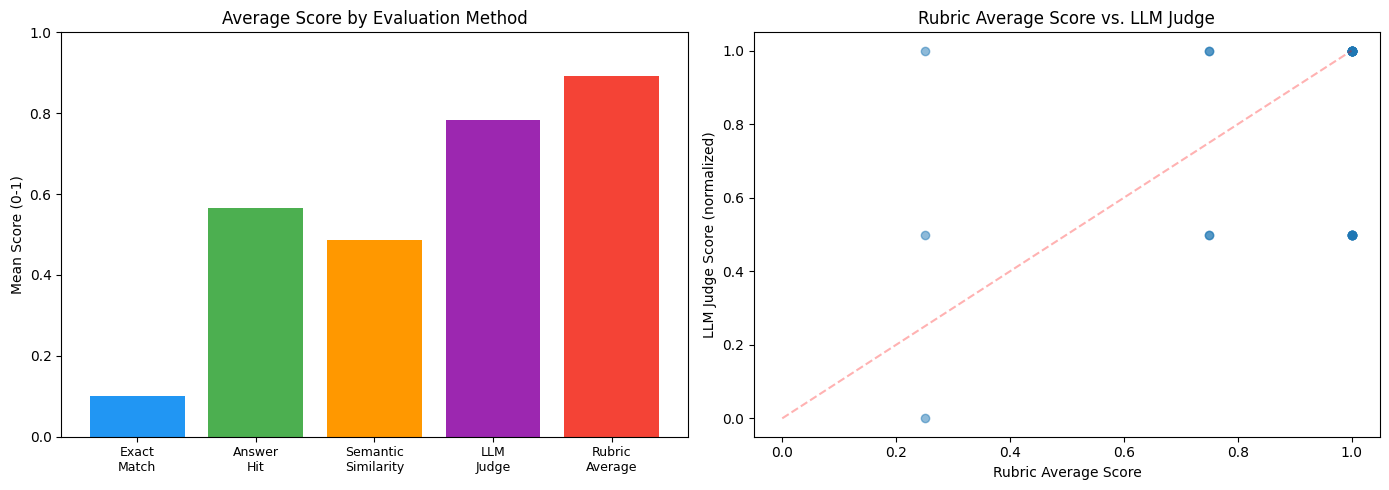

In [42]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of mean scores
means = df_compare.mean()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
axes[0].bar(range(len(means)), means.values, color=colors)
axes[0].set_xticks(range(len(means)))
axes[0].set_xticklabels(["Exact\nMatch", "Answer\nHit", "Semantic\nSimilarity", "LLM\nJudge", "Rubric\nAverage"], fontsize=9)
axes[0].set_ylabel("Mean Score (0-1)")
axes[0].set_title("Average Score by Evaluation Method")
axes[0].set_ylim(0, 1)

# Scatter: semantic similarity vs judge score
valid_both = df_compare.dropna(subset=["judge_score", "semantic_sim"])
axes[1].scatter(valid_both.rubric_avg, valid_both.judge_score, alpha=0.5)
axes[1].set_xlabel("Rubric Average Score")
axes[1].set_ylabel("LLM Judge Score (normalized)")
axes[1].set_title("Rubric Average Score vs. LLM Judge")
axes[1].plot([0, 1], [0, 1], "r--", alpha=0.3)

plt.tight_layout()
plt.show()

### Baselines for LLM Systems

Just as classification models need a majority-class baseline, LLM systems need their own:

1. **Zero-shot baseline**; the LLM with no optimization, no few-shot examples, no retrieval. This is the "out of the box" performance.
2. **No-retrieval baseline**; for RAG systems, run the LLM without any retrieved context. If retrieval does not improve the score, your retrieval pipeline is broken.
3. **No-optimization baseline**; for DSPy-style systems, compare the optimized prompt against the hand-written prompt from before optimization.

## 6. Choosing Your Metrics

### Decision Framework

Start from the **task**, not the metric:

| Task Type | Primary Metrics | Baselines |
|---|---|---|
| **Classification** | Precision, Recall, F1, AUROC, AUPRC | Majority Class, Random |
| **Regression** | MSE, MAE, Percentage within Tolerance | Mean, Median, Lag Values |
| **Retrieval (Search, Recommendation, RAG)** | Precision/Recall/Hit Rate@k, mAP, MRR | Random, Most Popular |
| **LLM generation** | Answer hit, semantic similarity, LLM-as-Judge, Rubric | Zero-shot, No-retrieval, No-optimization |

### Domain-Specific Metrics

This notebook covers the foundational metrics that apply across most AI/ML systems. Each task you saw in Lesson 2 has its own specialized metrics. Here is a reference so you know what to look for:

**Images**

| Task | Common Metrics |
|---|---|
| Image classification | Accuracy, Precision, Recall, F1 |
| Object detection | IoU (Intersection over Union), mAP (COCO-style) |
| Image segmentation | Dice coefficient, mIoU (Mean Intersection over Union) |
| Image captioning | BLEU, METEOR, CIDEr, CLIP score |
| Visual question answering | Accuracy, answer hit, semantic similarity |
| Image generation | FID (Fréchet Inception Distance), IS (Inception Score), CLIP score |
| Depth estimation | Absolute relative error, RMSE, δ-threshold accuracy |
| Pose estimation | PCK (Percentage of Correct Keypoints), OKS (Object Keypoint Similarity) |

**Text**

| Task | Common Metrics |
|---|---|
| Text classification | Accuracy, Precision, Recall, F1 |
| Named entity recognition | Entity-level F1, span-level F1 |
| Question answering | Exact match, F1 (token overlap), answer hit, semantic similarity |
| Machine translation | BLEU, chrF, COMET, BERTScore |
| Summarization | ROUGE (ROUGE-1, ROUGE-2, ROUGE-L), BERTScore |
| Text generation | Perplexity, human evaluation, LLM-as-Judge |
| Retrieval / semantic search | Precision/Recall@k, mAP, MRR, NDCG |

**Speech and Audio**

| Task | Common Metrics |
|---|---|
| Speech recognition (ASR) | WER (Word Error Rate), CER (Character Error Rate) |
| Text-to-speech | MOS (Mean Opinion Score), PESQ (Perceptual Evaluation of Speech Quality) |
| Speaker recognition | EER (Equal Error Rate), accuracy |
| Audio classification | Accuracy, F1 |

**Tabular**

| Task | Common Metrics |
|---|---|
| Classification | Accuracy, F1, AUROC, AUPRC |
| Regression | MSE, MAE, percentage within tolerance |
| Time series forecasting | MSE, MAE, sMAPE, MASE, percentage within tolerance |
| Recommendation | Precision/Recall@k, mAP, MRR, NDCG |
| Anomaly detection | Precision, Recall, F1, AUROC |
| Clustering | Silhouette score, ARI (Adjusted Rand Index), AMI (Adjusted Mutual Information) |

### Key Takeaways

- **Always plot first.** Confusion matrices, distribution plots, and scatter plots tell you more than any single number.
- **Always compare against baselines.** A model that cannot beat majority-class or mean prediction has not learned anything.
- **Choose metrics that lead to actions.** If a metric goes down, you should know what to fix. Rubric-based scoring is powerful precisely because it tells you *where* the model fails.
- **Macro-average over micro-average** when classes are imbalanced, unless you explicitly care more about the common classes.
- **For LLM systems**, combine fast automated metrics (semantic similarity) with slower but richer evaluation (LLM-as-Judge, rubrics)


### Metric is NOT the Goal

The goal is to build something useful. The metric is just a tool to help you get there. As [Goodhart's Law](https://en.wikipedia.org/wiki/Goodhart%27s_law) puts it: 

> When a measure becomes a target, it ceases to be a good measure.

The moment you optimize for a number instead of the underlying quality it represents, you start gaming the metric and your system gets worse at the thing that actually matters.

## Reflection Questions

1. You are building a spam filter. 95% of emails are not spam. Which metric would you optimize: accuracy, precision, recall, or F1? Why? What would your baseline be?

2. You are building a movie recommendation system. A user sees the top 5 recommendations on the home page. Which ranking metric best captures the user experience? What if the user scrolls through 50 results?

3. You built a RAG-powered chatbot that answers questions about company policy documents. How would you evaluate it? Which combination of metrics from this lesson would you use, and why?

4. An LLM-as-Judge gives your model a score of 1.8/2.0. A semantic similarity check gives 0.65. Which do you trust more? What might explain the disagreement?

5. Why is the harmonic mean used for F1 instead of the arithmetic mean? Hint: what happens when precision = 1.0 and recall = 0.01?

## What's Next

In Lesson 3b, we will go deeper into the mechanics of training: implementing SGD from scratch and understanding how gradient descent actually optimizes model weights. The metrics you learned here are what you will use to evaluate whether that training is working.

In Lessons 4–6, you will apply these metrics to specific domains: agentic systems, tabular data, NLP, and computer visionーeach with their own specialized metrics built on the same foundations.